<a href="https://colab.research.google.com/github/shifu027/TCC-Pyomo/blob/main/Poymo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instalação da biblioteca Pyomo para modelagem de otimização
!pip install pyomo
# Instalação das bibliotecas padrão para manipulação de dados e visualização
!pip install pandas numpy matplotlib
# Comando para instalar o solver CBC usando o gerenciador de pacotes do Linux
!apt-get install -y -qq coinor-cbc
!apt-get update -qq
!apt-get install -y -qq glpk-utils
!pip install pyomo==6.7.1 seaborn==0.13.2 matplotlib==3.9.0 pandas==2.2.2

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
# Importação das bibliotecas necessárias
import pyomo.environ as pyo
import pandas as pd
import numpy as np
import os
from google.colab import drive

print("Bibliotecas e solver instalados com sucesso.")

Bibliotecas e solver instalados com sucesso.


In [3]:
drive.mount('/content/drive')
path_to_data = '/content/drive/MyDrive/TCC_DATA_FILES/'

# --- Carregar dados de entrada ---
general_params = pd.read_csv(path_to_data + 'general_parameters.csv', sep=',')
load_profiles = pd.read_csv(path_to_data + 'load_profiles.csv', sep=',')
pv_profiles = pd.read_csv(path_to_data + 'pv_profiles.csv', sep=',')
ev_params = pd.read_csv(path_to_data + 'ev_parameters.csv', sep=',')
tariffs = pd.read_csv(path_to_data + 'energy_tariffs.csv', sep=',')
network_params = pd.read_csv(path_to_data + 'network_parameters.csv', sep=',')

print("Arquivos carregados com sucesso!")

Mounted at /content/drive
Arquivos carregados com sucesso!


In [4]:
import shutil
print("cbc path:", shutil.which("cbc"))
print("glpsol path:", shutil.which("glpsol"))

cbc path: /usr/bin/cbc
glpsol path: /usr/bin/glpsol


In [5]:
# -*- coding: utf-8 -*-
"""
======================================================================================================
SCRIPT DE OTIMIZAÇÃO E ANÁLISE VISUAL DE CENÁRIOS (VERSÃO TCC + Q em LinDistFlow)
======================================================================================================
Alterações principais (patch Q):
- Variáveis reativas: Q_grid[t], Q_ramo[i,j,t]
- Balanço de reativo por nó e hora (carga com PF; DERs com Q=0 por padrão)
- Queda de tensão LinDistFlow com R*P + X*Q (p.u.)
- Limites lineares para P e Q por ramo
- Suporte a X via coluna 'reactance_ohm' ou estimativa X/R padrão

Compatível com CBC. Mantém seus gráficos e KPIs.
======================================================================================================
"""

# ####################################################################################################
# ETAPA 1: CONFIGURAÇÃO DO AMBIENTE E DEPENDÊNCIAS
# ####################################################################################################
print(">>> ETAPA 1: Configurando o ambiente...")
try:
    import pyomo.environ as pyo
except ImportError:
    # Colab-only helpers
    !pip install -q pyomo
    !apt-get -y -qq install coinor-cbc

import pandas as pd
import pyomo.environ as pyo
import matplotlib.pyplot as plt
import numpy as np
import io
# seaborn é usado nos seus gráficos originais
import seaborn as sns
from IPython.display import display

print("Ambiente configurado com sucesso.")

# ####################################################################################################
# ETAPA 2: DADOS DE ENTRADA E PRÉ-PROCESSAMENTO
# ####################################################################################################
print("\n>>> ETAPA 2: Gerando e carregando arquivos de dados...")

# === Parâmetros principais (mantidos) ===
fator_de_escala_da_carga = 5.0
print(f"AVISO: A carga da rede foi multiplicada por {fator_de_escala_da_carga}x para fins de visualização.")

# Incluí pf_carga (0,95 indutivo) e um X/R padrão (0,8) para quando a rede não informar reactance_ohm
general_params_csv = """parametro,valor,unidade
capacidade_bess_kwh,100,kWh
pot_max_carga_bess_kw,50,kW
pot_max_descarga_bess_kw,40,kW
eficiencia_carga_bess,0.92,-
eficiencia_descarga_bess,0.90,-
soc_min_bess_pu,0.20,p.u.
soc_max_bess_pu,0.95,p.u.
soc_inicial_bess_pu,0.50,p.u.
custo_degradacao_bess_r_kwh,0.10,R$/kWh
custo_degradacao_ve_r_kwh,0.05,R$/kWh
custo_curtailment_pv_r_kwh,0.02,R$/kWh
custo_demanda_pico_r_kw,45.0,R$/kW
delta_t_h,1.0,h
v_base_kv,13.8,kV
s_base_mva,1.0,MVA
v_min_pu,0.95,p.u.
v_max_pu,1.05,p.u.
pf_carga,0.95,cosphi
x_over_r_default,0.80,ratio
""".strip()

tariffs_csv = """hora,tarifa_r_kwh
0,0.60
1,0.60
2,0.60
3,0.60
4,0.60
5,0.60
6,0.60
7,0.75
8,0.75
9,0.75
10,0.75
11,0.75
12,0.75
13,0.75
14,0.75
15,0.75
16,0.75
17,1.20
18,1.20
19,1.20
20,0.75
21,0.60
22,0.60
23,0.60
""".strip()

# Perfis (mantidos do seu script)
t_range = np.arange(24)
base_load = 40 + 30 * np.sin(np.pi * (t_range - 8) / 12)
peak_load = 1.8 * np.exp(-((t_range - 19)**2) / 4)
total_load_profile = base_load * peak_load * 2.5 * fator_de_escala_da_carga

load_profiles_df_gen = pd.DataFrame({'hora': t_range})
load_profiles_df_gen['load_kw_2'] = total_load_profile * 0.4
load_profiles_df_gen['load_kw_4'] = total_load_profile * 0.35
load_profiles_df_gen['load_kw_5'] = total_load_profile * 0.25
load_profiles_csv = load_profiles_df_gen.to_csv(index=False)

pv_profile = 100 * np.maximum(0, np.sin(np.pi * (t_range - 6) / 12))
pv_profiles_df_gen = pd.DataFrame({'hora': t_range, 'pv_kw_4': pv_profile})
pv_profiles_csv = pv_profiles_df_gen.to_csv(index=False)

ev_params_csv = """ve_id,capacidade_kwh,p_max_carga_kw,p_max_descarga_kw,ef_carga,ef_descarga,soc_inicial_pu,soc_alvo_pu,t_chegada,t_partida,aceita_v2g_b
0,50,7.2,3.7,0.95,0.95,0.40,0.9,18,7,1
1,60,11.0,5.0,0.96,0.94,0.50,0.9,19,8,0
2,45,7.2,3.7,0.95,0.95,0.30,0.8,17,6,1
3,75,22.0,11.0,0.97,0.96,0.60,0.95,20,7,0
""".strip()

# REDE: se não houver reactance_ohm na sua base real, usamos o X/R padrão
network_params_csv = """from_node,to_node,resistance_ohm,p_max_kw
0,1,0.05,2000
1,2,0.10,500
1,3,0.12,500
3,4,0.15,400
1,5,0.08,500
""".strip()

# Leitura
general_df = pd.read_csv(io.StringIO(general_params_csv)).set_index('parametro')
tariffs_df = pd.read_csv(io.StringIO(tariffs_csv))
load_profiles_df = pd.read_csv(io.StringIO(load_profiles_csv))
pv_profiles_df = pd.read_csv(io.StringIO(pv_profiles_csv))
ev_parameters_df = pd.read_csv(io.StringIO(ev_params_csv))
network_parameters_df = pd.read_csv(io.StringIO(network_params_csv))

# Conjuntos
T = sorted([int(h) for h in tariffs_df['hora'].unique()])
T_list = list(T)
N_nodes = sorted([int(n) for n in pd.unique(network_parameters_df[['from_node', 'to_node']].values.ravel('K'))])
V = sorted([int(v) for v in ev_parameters_df['ve_id'].unique()])
E_branches = [tuple(int(x) for x in row) for row in network_parameters_df[['from_node', 'to_node']].values]

children_of = {n: [j for i, j in E_branches if i == n] for n in N_nodes}
parent_of = {j: i for i, j in E_branches}

# Parâmetros numéricos
params = {}
params['delta_t'] = float(general_df.loc['delta_t_h', 'valor'])
params['V_base_kv'] = float(general_df.loc['v_base_kv', 'valor'])
params['S_base_mva'] = float(general_df.loc['s_base_mva', 'valor'])
params['S_base_kw'] = params['S_base_mva'] * 1000.0
params['Z_base_ohm'] = (params['V_base_kv']**2) / params['S_base_mva']  # 3φ simplificado

params['C_pico'] = float(general_df.loc['custo_demanda_pico_r_kw', 'valor'])
params['C_curt'] = float(general_df.loc['custo_curtailment_pv_r_kwh', 'valor'])
params['C_deg_BESS'] = float(general_df.loc['custo_degradacao_bess_r_kwh', 'valor'])
params['C_deg_VE'] = float(general_df.loc['custo_degradacao_ve_r_kwh', 'valor'])

params['SoC_min_BESS_pu'] = float(general_df.loc['soc_min_bess_pu', 'valor'])
params['SoC_max_BESS_pu'] = float(general_df.loc['soc_max_bess_pu', 'valor'])
params['SoC_init_BESS_pu'] = float(general_df.loc['soc_inicial_bess_pu', 'valor'])

params['Pmax_ch_BESS_kw'] = float(general_df.loc['pot_max_carga_bess_kw', 'valor'])
params['Pmax_dis_BESS_kw'] = float(general_df.loc['pot_max_descarga_bess_kw', 'valor'])
params['eta_ch_BESS'] = float(general_df.loc['eficiencia_carga_bess', 'valor'])
params['eta_dis_BESS'] = float(general_df.loc['eficiencia_descarga_bess', 'valor'])

params['C_energia'] = tariffs_df.set_index('hora')['tarifa_r_kwh'].astype(float).to_dict()

# Cargas ativas P_carga(j,t)
params['P_carga'] = {}
for t in T:
    for col in load_profiles_df.columns:
        if col.startswith('load_kw_'):
            j = int(col.split('_')[-1])
            vals = load_profiles_df.loc[load_profiles_df['hora'] == t, col].values
            params['P_carga'][(j, t)] = float(vals[0]) if len(vals) > 0 else 0.0

# PV (assumido PF ~ 1 -> Q_pv = 0)
params['P_pv'] = {}
for t in T:
    for col in pv_profiles_df.columns:
        if col.startswith('pv_kw_'):
            j = int(col.split('_')[-1])
            vals = pv_profiles_df.loc[pv_profiles_df['hora'] == t, col].values
            params['P_pv'][(j, t)] = float(vals[0]) if len(vals) > 0 else 0.0

# VEs
ev_map = ev_parameters_df.set_index('ve_id').to_dict('index')
params['Emax_VE'] = {i: float(ev_map[i]['capacidade_kwh']) for i in V}
params['Pmax_ch_VE'] = {i: float(ev_map[i]['p_max_carga_kw']) for i in V}
params['Pmax_dis_VE'] = {i: float(ev_map[i]['p_max_descarga_kw']) for i in V}
params['eta_ch_VE'] = {i: float(ev_map[i]['ef_carga']) for i in V}
params['eta_dis_VE'] = {i: float(ev_map[i]['ef_descarga']) for i in V}
params['SoC_init_VE_kwh'] = {i: float(ev_map[i]['soc_inicial_pu']) * float(ev_map[i]['capacidade_kwh']) for i in V}
params['SoC_target_VE_kwh'] = {i: float(ev_map[i]['soc_alvo_pu']) * float(ev_map[i]['capacidade_kwh']) for i in V}
params['t_chegada_VE'] = {i: int(ev_map[i]['t_chegada']) for i in V}
params['t_partida_VE'] = {i: int(ev_map[i]['t_partida']) for i in V}
params['b_v2g_VE'] = {i: int(ev_map[i]['aceita_v2g_b']) for i in V}

# Disponibilidade dos VEs
params['a_disp_VE'] = {}
for i in V:
    chegada, partida = params['t_chegada_VE'][i], params['t_partida_VE'][i]
    for t in T:
        if chegada > partida:
            params['a_disp_VE'][(i, t)] = 1 if (t >= chegada or t < partida) else 0
        else:
            params['a_disp_VE'][(i, t)] = 1 if (chegada <= t < partida) else 0

# Rede: R e (opcional) X
R_ohm = {(int(r['from_node']), int(r['to_node'])): float(r['resistance_ohm']) for _, r in network_parameters_df.iterrows()}

# Se houver reactance_ohm, usa. Senão estima X = R * (X/R)_default
x_over_r_default = float(general_df.loc['x_over_r_default', 'valor'])
if 'reactance_ohm' in network_parameters_df.columns:
    X_ohm = {(int(r['from_node']), int(r['to_node'])): float(r['reactance_ohm']) for _, r in network_parameters_df.iterrows()}
else:
    X_ohm = {k: v * x_over_r_default for k, v in R_ohm.items()}

params['R_pu'] = {k: v / params['Z_base_ohm'] for k, v in R_ohm.items()}
params['X_pu'] = {k: v / params['Z_base_ohm'] for k, v in X_ohm.items()}

# Limite de ramo (tratado como S_max linear para P e Q)
params['S_max_ramo_kw'] = {(int(r['from_node']), int(r['to_node'])): float(r['p_max_kw']) for _, r in network_parameters_df.iterrows()}

# Local dos recursos
params['BESS_node'] = 2
params['VE_nodes'] = {0: 2, 1: 4, 2: 4, 3: 5}

# Índices de tempo anteriores (SOE)
t_prev_map = {tt: T_list[idx - 1] if idx > 0 else T_list[-1] for idx, tt in enumerate(T_list)}

# === NOVO: Q de carga a partir de PF ===
pf_carga = float(general_df.loc['pf_carga', 'valor'])
phi = np.arccos(np.clip(pf_carga, -1.0, 1.0))
tanphi = np.tan(phi)
params['Q_carga'] = {(j, t): params['P_carga'].get((j, t), 0.0) * tanphi for j in N_nodes for t in T_list}

print("Pré-processamento concluído.")

# ####################################################################################################
# ETAPA 3: FUNÇÕES DE SIMULAÇÃO E OTIMIZAÇÃO
# ####################################################################################################
def run_optimization_scenario(params, v2g_enabled, bess_present):
    print(f"\n>>> Executando Otimização: V2G {'Habilitado' if v2g_enabled else 'Desabilitado'}, BESS {'Presente' if bess_present else 'Ausente'}")
    m = pyo.ConcreteModel()

    # Conjuntos
    m.T = pyo.Set(initialize=T)
    m.N = pyo.Set(initialize=N_nodes)
    m.VE = pyo.Set(initialize=V)
    m.E = pyo.Set(initialize=E_branches, dimen=2)

    # Variáveis de potência ativa existentes
    m.P_grid = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_max_pico = pyo.Var(domain=pyo.NonNegativeReals)
    m.P_curt = pyo.Var(m.N, m.T, domain=pyo.NonNegativeReals)

    m.P_bess_ch = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_bess_dis = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.SoC_BESS = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.u_BESS = pyo.Var(m.T, domain=pyo.Binary)

    m.P_ve_ch = pyo.Var(m.VE, m.T, domain=pyo.NonNegativeReals)
    m.P_ve_dis = pyo.Var(m.VE, m.T, domain=pyo.NonNegativeReals)
    m.SoC_VE = pyo.Var(m.VE, m.T, domain=pyo.NonNegativeReals)
    m.u_VE = pyo.Var(m.VE, m.T, domain=pyo.Binary)

    m.P_ramo = pyo.Var(m.E, m.T, domain=pyo.Reals)

    # === NOVO: variáveis reativas ===
    m.Q_grid = pyo.Var(m.T, domain=pyo.Reals)             # não há custo, apenas balanço
    m.Q_ramo = pyo.Var(m.E, m.T, domain=pyo.Reals)

    # Tensão (quadrado) por nó/hora
    m.V2_no = pyo.Var(m.N, m.T, domain=pyo.NonNegativeReals)

    # Objetivo (inalterado)
    def objective_rule(m):
        custo_energia = sum(params['C_energia'][t] * m.P_grid[t] * params['delta_t'] for t in m.T)
        custo_pico = params['C_pico'] * m.P_max_pico
        custo_curt = sum(params['C_curt'] * m.P_curt[j, t] * params['delta_t'] for j in m.N for t in m.T)
        custo_deg_bess = sum(params['C_deg_BESS'] * (m.P_bess_ch[t] + m.P_bess_dis[t]) * params['delta_t'] for t in m.T if bess_present)
        custo_deg_ve = sum(params['C_deg_VE'] * (m.P_ve_ch[i, t] + m.P_ve_dis[i, t]) * params['delta_t'] for i in m.VE for t in m.T)
        return custo_energia + custo_pico + custo_curt + custo_deg_bess + custo_deg_ve
    m.objective = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

    # Pico
    m.peak_demand_constraint = pyo.Constraint(m.T, rule=lambda m, t: m.P_grid[t] <= m.P_max_pico)

    # Curtailment não pode exceder PV
    m.curtailment_limit_constraint = pyo.Constraint(m.N, m.T, rule=lambda m, j, t: m.P_curt[j, t] <= params['P_pv'].get((j, t), 0.0))

    # BESS
    if bess_present:
        Emax_BESS_kwh = float(general_df.loc['capacidade_bess_kwh', 'valor'])
        SoC_min_BESS_kwh = params['SoC_min_BESS_pu'] * Emax_BESS_kwh
        SoC_max_BESS_kwh = params['SoC_max_BESS_pu'] * Emax_BESS_kwh
        SoC_init_BESS_kwh = params['SoC_init_BESS_pu'] * Emax_BESS_kwh

        def bess_soc_rule(m, t):
            t_prev = t_prev_map[t]
            soc_prev = SoC_init_BESS_kwh if t == T_list[0] else m.SoC_BESS[t_prev]
            return m.SoC_BESS[t] == soc_prev + (m.P_bess_ch[t] * params['eta_ch_BESS'] - m.P_bess_dis[t] / params['eta_dis_BESS']) * params['delta_t']
        m.bess_soc_constraint = pyo.Constraint(m.T, rule=bess_soc_rule)

        m.bess_soc_limits_constraint = pyo.Constraint(m.T, rule=lambda m, t: pyo.inequality(SoC_min_BESS_kwh, m.SoC_BESS[t], SoC_max_BESS_kwh))
        m.bess_charge_limit_constraint = pyo.Constraint(m.T, rule=lambda m, t: m.P_bess_ch[t] <= params['Pmax_ch_BESS_kw'] * m.u_BESS[t])
        m.bess_discharge_limit_constraint = pyo.Constraint(m.T, rule=lambda m, t: m.P_bess_dis[t] <= params['Pmax_dis_BESS_kw'] * (1 - m.u_BESS[t]))
    else:
        m.bess_zero_power = pyo.Constraint(m.T, rule=lambda m, t: (m.P_bess_ch[t] == 0) & (m.P_bess_dis[t] == 0))

    # VEs (SoC)
    def ve_soc_rule(m, i, t):
        t_prev = t_prev_map[t]
        soc_prev = params['SoC_init_VE_kwh'][i] if t == T_list[0] else m.SoC_VE[i, t_prev]
        return m.SoC_VE[i, t] == soc_prev + (m.P_ve_ch[i, t] * params['eta_ch_VE'][i] - m.P_ve_dis[i, t] / params['eta_dis_VE'][i]) * params['delta_t']
    m.ve_soc_constraint = pyo.Constraint(m.VE, m.T, rule=ve_soc_rule)

    m.ve_charge_limit_constraint = pyo.Constraint(m.VE, m.T, rule=lambda m, i, t: m.P_ve_ch[i, t] <= params['Pmax_ch_VE'][i] * params['a_disp_VE'][(i, t)] * m.u_VE[i, t])
    m.ve_discharge_limit_constraint = pyo.Constraint(m.VE, m.T, rule=lambda m, i, t: m.P_ve_dis[i, t] <= params['Pmax_dis_VE'][i] * params['a_disp_VE'][(i, t)] * (params['b_v2g_VE'][i] if v2g_enabled else 0) * (1 - m.u_VE[i, t]))

    # Meta de SoC na partida
    def ve_soc_target_rule(m, i):
        t_partida = params['t_partida_VE'][i]
        t_idx = t_partida - 1 if t_partida > 0 else T_list[-1]
        return m.SoC_VE[i, t_idx] >= params['SoC_target_VE_kwh'][i]
    m.ve_soc_target_constraint = pyo.Constraint(m.VE, rule=ve_soc_target_rule)

    # === Balanço nodal de POTÊNCIA ATIVA (P) ===
    def nodal_P_balance(m, j, t):
        if j == 0:
            # Slack: P_grid = soma dos fluxos que saem do nó 0
            return m.P_grid[t] == sum(m.P_ramo[0, k, t] for (jf, k) in m.E if jf == 0)
        parent_n = parent_of.get(j, None)
        if parent_n is None:
            return pyo.Constraint.Skip
        fluxo_entrada = m.P_ramo[parent_n, j, t]
        fluxo_saida = sum(m.P_ramo[j, k, t] for k in children_of.get(j, []))
        inj_pv = params['P_pv'].get((j, t), 0.0) - m.P_curt[j, t]
        inj_bess = (m.P_bess_dis[t] - m.P_bess_ch[t]) if (j == params['BESS_node'] and bess_present) else 0.0
        inj_ves = sum(m.P_ve_dis[i, t] - m.P_ve_ch[i, t] for i in m.VE if params['VE_nodes'].get(i, None) == j)
        carga = params['P_carga'].get((j, t), 0.0)
        return fluxo_entrada - fluxo_saida == carga - (inj_pv + inj_bess + inj_ves)
    m.nodal_power_balance_constraint = pyo.Constraint(m.N, m.T, rule=nodal_P_balance)

    # === NOVO: Balanço nodal de POTÊNCIA REATIVA (Q) ===
    def nodal_Q_balance(m, j, t):
        if j == 0:
            # Slack reativo: variável livre (sem custo)
            return m.Q_grid[t] == sum(m.Q_ramo[0, k, t] for (jf, k) in m.E if jf == 0)
        parent_n = parent_of.get(j, None)
        if parent_n is None:
            return pyo.Constraint.Skip
        fluxo_entrada = m.Q_ramo[parent_n, j, t]
        fluxo_saida = sum(m.Q_ramo[j, k, t] for k in children_of.get(j, []))
        # DERs com Q=0 (padrão). Se quiser habilitar suporte reativo, adicionar Q_bess/Q_ve aqui.
        inj_Q_der = 0.0
        q_carga = params['Q_carga'][(j, t)]
        return fluxo_entrada - fluxo_saida == q_carga - inj_Q_der
    m.nodal_reactive_balance_constraint = pyo.Constraint(m.N, m.T, rule=nodal_Q_balance)

    # === Queda de tensão LinDistFlow (p.u.) com R*P + X*Q ===
    @m.Constraint(m.E, m.T)
    def voltage_drop_constraint(m, i, j, t):
        p_pu = m.P_ramo[i, j, t] / params['S_base_kw']
        q_pu = m.Q_ramo[i, j, t] / params['S_base_kw']
        return m.V2_no[j, t] == m.V2_no[i, t] - 2.0 * (params['R_pu'][(i, j)] * p_pu + params['X_pu'][(i, j)] * q_pu)

    # Slack V^2 = 1.0
    m.slack_bus_voltage_constraint = pyo.Constraint(m.T, rule=lambda m, t: m.V2_no[0, t] == 1.0**2)

    # Limites de tensão
    V_min_sq = float(general_df.loc['v_min_pu', 'valor'])**2
    V_max_sq = float(general_df.loc['v_max_pu', 'valor'])**2
    m.voltage_limits_constraint = pyo.Constraint(m.N, m.T, rule=lambda m, j, t: pyo.inequality(V_min_sq, m.V2_no[j, t], V_max_sq))

    # === Limites lineares de ramo (box) para P e Q: |P| <= Smax, |Q| <= Smax ===
    m.branch_P_limits = pyo.Constraint(m.E, m.T, rule=lambda m, i, j, t: pyo.inequality(-params['S_max_ramo_kw'][(i, j)], m.P_ramo[i, j, t], params['S_max_ramo_kw'][(i, j)]))
    m.branch_Q_limits = pyo.Constraint(m.E, m.T, rule=lambda m, i, j, t: pyo.inequality(-params['S_max_ramo_kw'][(i, j)], m.Q_ramo[i, j, t], params['S_max_ramo_kw'][(i, j)]))

    # Solver
    solver = pyo.SolverFactory('cbc')
    results = solver.solve(m, tee=False)

    if (results.solver.status == pyo.SolverStatus.ok) and (results.solver.termination_condition == pyo.TerminationCondition.optimal):
        print("Solução ótima encontrada!")
        return results, m
    else:
        print("Atenção: solução não ótima.")
        return results, m

def simulate_bau_scenario(params):
    """Cenário BAU (sem otimização): mantido e estendido para registrar V e fluxos com Q."""
    print("\n>>> Simulando Cenário Base (BAU)...")
    df = pd.DataFrame(index=T_list); df.index.name = 'hora'

    # Carga de VE "pior caso" (como já fazia): máximo quando presente
    p_ve_ch_nodal = {(j, t): 0.0 for j in N_nodes for t in T_list}
    for i in V:
        ve_node = params['VE_nodes'][i]
        for t in T_list:
            if params['a_disp_VE'][(i, t)] == 1:
                p_ve_ch_nodal[ve_node, t] += params['Pmax_ch_VE'][i]

    # Injeção líquida nodal ativa (PV - carga - VE carga)
    p_inj_nodal = {(j, t): params['P_pv'].get((j, t), 0.0) - params['P_carga'].get((j, t), 0.0) - p_ve_ch_nodal.get((j, t), 0.0)
                   for j in N_nodes for t in T_list}

    # Fluxos aproximados radial (de folhas ao slack) — P e Q
    p_ramo, q_ramo, v2 = {}, {}, {}
    for t in T_list:
        # Potência líquida que cada nó precisa receber do pai (positiva = demanda)
        p_fluxo_nodal = {j: -p_inj_nodal[j, t] for j in N_nodes}
        q_fluxo_nodal = {j: params['Q_carga'][(j, t)] for j in N_nodes}  # PV e DER com Q~0

        # Sobe agregando para o pai (radial)
        for j in sorted(N_nodes, reverse=True):
            if j != 0:
                p_ramo[parent_of[j], j, t] = p_fluxo_nodal[j] + sum(p_ramo.get((j, k, t), 0.0) for k in children_of.get(j, []))
                q_ramo[parent_of[j], j, t] = q_fluxo_nodal[j] + sum(q_ramo.get((j, k, t), 0.0) for k in children_of.get(j, []))

        # Queda de tensão (forward)
        v2[0, t] = 1.0
        nodes_to_process = list(children_of.get(0, []))
        head = 0
        while head < len(nodes_to_process):
            j = nodes_to_process[head]
            i = parent_of[j]
            p_pu = (p_ramo.get((i, j, t), 0.0)) / params['S_base_kw']
            q_pu = (q_ramo.get((i, j, t), 0.0)) / params['S_base_kw']
            v2[j, t] = v2[(i, t)] - 2.0 * (params['R_pu'][(i, j)] * p_pu + params['X_pu'][(i, j)] * q_pu)
            nodes_to_process.extend(children_of.get(j, []))
            head += 1

    # Saídas principais BAU
    df['P_grid_kW'] = [sum(p_ramo.get((0, k, t), 0.0) for k in children_of.get(0, [])) for t in T_list]
    df['P_grid_kW'] = df['P_grid_kW'].clip(lower=0)
    df['P_carga_total_kW'] = [sum(params['P_carga'].get((j, t), 0.0) for j in N_nodes) for t in T_list]
    df['P_pv_total_kW'] = [sum(params['P_pv'].get((j, t), 0.0) for j in N_nodes) for t in T_list]
    df['P_ve_ch_total_kW'] = [sum(p_ve_ch_nodal.get((j, t), 0.0) for j in N_nodes) for t in T_list]
    df['P_ve_dis_total_kW'] = 0.0
    df['P_curt_total_kW'] = (df['P_pv_total_kW'] - (df['P_carga_total_kW'] + df['P_ve_ch_total_kW'] - df['P_grid_kW'])).clip(lower=0)

    df['P_bess_ch_kW'] = 0.0; df['P_bess_dis_kW'] = 0.0; df['SoC_BESS_kWh'] = 0.0
    for j in N_nodes:
        df[f'V_no_{j}_pu'] = [np.sqrt(max(v2.get((j, t), 1.0), 0.0)) for t in T_list]  # clamp numérico

    pico = df['P_grid_kW'].max()
    custo_energia = (df['P_grid_kW'] * pd.Series(params['C_energia']) * params['delta_t']).sum()
    custo_pico = params['C_pico'] * pico
    custo_degradacao = (df['P_ve_ch_total_kW'] * params['C_deg_VE'] * params['delta_t']).sum()
    kpis = {'Custo de Energia': custo_energia, 'Custo de Demanda': custo_pico, 'Custo de Degradação': custo_degradacao}

    detalhes = {}
    ramoP_df = pd.DataFrame(index=T_list, columns=[f'{i}-{j}' for i, j in E_branches])
    ramoQ_df = pd.DataFrame(index=T_list, columns=[f'{i}-{j}' for i, j in E_branches])
    for t in T_list:
        for i, j in E_branches:
            ramoP_df.loc[t, f'{i}-{j}'] = p_ramo.get((i, j, t), 0.0)
            ramoQ_df.loc[t, f'{i}-{j}'] = q_ramo.get((i, j, t), 0.0)
    detalhes['ramoP_df'] = ramoP_df
    detalhes['ramoQ_df'] = ramoQ_df

    return df, kpis, detalhes

# ####################################################################################################
# ETAPAS 4, 5 e 6: EXECUÇÃO, EXTRAÇÃO E PROCESSAMENTO
# ####################################################################################################
print("\n" + "="*80 + "\n>>> ETAPAS 4, 5, 6: EXECUTANDO CENÁRIOS E PROCESSANDO DADOS\n" + "="*80)
results_repo = {}

# BAU
results_repo['BAU'] = {}
results_repo['BAU']['agregado'], results_repo['BAU']['kpis'], results_repo['BAU']['detalhado'] = simulate_bau_scenario(params)

# Otimizados
scenarios_opt = {
    'BESS+V1G': {'v2g': False, 'bess': True},
    'BESS+V2G': {'v2g': True,  'bess': True}
}
for name, cfg in scenarios_opt.items():
    results, m = run_optimization_scenario(params, v2g_enabled=cfg['v2g'], bess_present=cfg['bess'])
    if m is None:
        continue
    results_repo[name] = {}
    agg = pd.DataFrame(index=T_list)
    agg['P_grid_kW'] = [pyo.value(m.P_grid[t]) for t in T_list]
    agg['P_carga_total_kW'] = [sum(params['P_carga'].get((j, t), 0.0) for j in N_nodes) for t in T_list]
    agg['P_pv_total_kW'] = [sum(params['P_pv'].get((j, t), 0.0) for j in N_nodes) for t in T_list]
    agg['P_curt_total_kW'] = [sum(pyo.value(m.P_curt[j, t]) for j in N_nodes) for t in T_list]
    agg['P_bess_ch_kW'] = [pyo.value(m.P_bess_ch[t]) for t in T_list]
    agg['P_bess_dis_kW'] = [pyo.value(m.P_bess_dis[t]) for t in T_list]
    agg['SoC_BESS_kWh'] = [pyo.value(m.SoC_BESS[t]) if cfg['bess'] else 0.0 for t in T_list]
    agg['P_ve_ch_total_kW'] = [sum(pyo.value(m.P_ve_ch[i, t]) for i in V) for t in T_list]
    agg['P_ve_dis_total_kW'] = [sum(pyo.value(m.P_ve_dis[i, t]) for i in V) for t in T_list]
    for j in N_nodes:
        agg[f'V_no_{j}_pu'] = [np.sqrt(max(pyo.value(m.V2_no[j, t]), 0.0)) for t in T_list]
    results_repo[name]['agregado'] = agg

    custos = {
        'Custo de Energia': sum(params['C_energia'][t] * pyo.value(m.P_grid[t]) * params['delta_t'] for t in T_list),
        'Custo de Demanda': params['C_pico'] * pyo.value(m.P_max_pico),
        'Custo de Degradação': pyo.value(
            sum(params['C_deg_BESS'] * (m.P_bess_ch[t] + m.P_bess_dis[t]) * params['delta_t'] for t in T_list if cfg['bess'])
            + sum(params['C_deg_VE'] * (m.P_ve_ch[i, t] + m.P_ve_dis[i, t]) * params['delta_t'] for i in V for t in T_list)
        )
    }
    results_repo[name]['kpis'] = custos

    det = {}
    soc_ve_df = pd.DataFrame({f'VE_{i}': [pyo.value(m.SoC_VE[i, t]) for t in T_list] for i in V}, index=T_list)
    det['soc_ve_df'] = soc_ve_df

    ramoP_df = pd.DataFrame(index=T_list, columns=[f'{i}-{j}' for i, j in E_branches])
    ramoQ_df = pd.DataFrame(index=T_list, columns=[f'{i}-{j}' for i, j in E_branches])
    for t in T_list:
        for i, j in E_branches:
            ramoP_df.loc[t, f'{i}-{j}'] = pyo.value(m.P_ramo[i, j, t])
            ramoQ_df.loc[t, f'{i}-{j}'] = pyo.value(m.Q_ramo[i, j, t])
    det['ramoP_df'] = ramoP_df
    det['ramoQ_df'] = ramoQ_df

    results_repo[name]['detalhado'] = det

print("Processamento de todos os cenários concluído.")

# ####################################################################################################
# ETAPA 7: VISUALIZAÇÕES (mantidas do seu script original)
# ####################################################################################################
plt.style.use('seaborn-v0_8-whitegrid')

def plot_despacho_comparativo(results_repo):
    fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)
    fig.suptitle('Comparativo de Despacho Agregado de Potência', fontsize=18)

    scenarios_to_plot = ['BAU', 'BESS+V1G', 'BESS+V2G']
    legend_elements = {}

    for ax, scenario in zip(axes, scenarios_to_plot):
        df = results_repo[scenario]['agregado']
        pv_net = df['P_pv_total_kW'] - df['P_curt_total_kW']

        series_data = {'Rede': df['P_grid_kW'], 'PV Líquida': pv_net, 'BESS (Desc)': df['P_bess_dis_kW'], 'VEs (V2G)': df['P_ve_dis_total_kW']}
        colors = {'Rede': '#FF6347', 'PV Líquida': '#FFD700', 'BESS (Desc)': '#1E90FF', 'VEs (V2G)': '#32CD32'}

        if scenario == 'BAU':
            plot_order = ['Rede', 'PV Líquida']
        elif scenario == 'BESS+V1G':
            plot_order = ['Rede', 'PV Líquida', 'BESS (Desc)']
        else:
            plot_order = ['Rede', 'PV Líquida', 'BESS (Desc)', 'VEs (V2G)']

        stack = ax.stackplot(df.index, [series_data[k] for k in plot_order], labels=plot_order, colors=[colors[k] for k in plot_order])
        demanda_line, = ax.plot(df.index, df['P_carga_total_kW'] + df['P_ve_ch_total_kW'] + df['P_bess_ch_kW'], 'k--', lw=2.5, label='Demanda Total')
        for i, handle in enumerate(stack):
            legend_elements[plot_order[i]] = handle
        legend_elements['Demanda Total'] = demanda_line

        ax.set_title(f'Cenário: {scenario}', fontsize=14)
        ax.set_xlabel('Hora do Dia')
        ax.grid(True)
        ax.set_xlim(0, 23)

    axes[0].set_ylabel('Potência (kW)')
    final_labels = ['Rede', 'BESS (Desc)', 'VEs (V2G)', 'PV Líquida', 'Demanda Total']
    final_handles = [legend_elements[lbl] for lbl in final_labels if lbl in legend_elements]
    fig.legend(final_handles, [lbl for lbl in final_labels if lbl in legend_elements], loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=5, fontsize=14)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

def plot_despacho_comparativo2(results_repo):
    scenarios_to_plot = ['BAU', 'BESS+V1G', 'BESS+V2G']
    for scenario in scenarios_to_plot:
        plt.figure(figsize=(12, 7))
        ax = plt.gca()
        df = results_repo[scenario]['agregado']
        pv_net = df['P_pv_total_kW'] - df['P_curt_total_kW']
        if scenario == 'BESS+V1G':
            ax.stackplot(df.index, df['P_grid_kW'], df['P_bess_dis_kW'], pv_net,
                         labels=['Rede', 'BESS (Desc)', 'PV Líquida'],
                         colors=['#FF6347', '#1E90FF', '#FFD700'])
        else:
            ax.stackplot(df.index, df['P_grid_kW'], df['P_bess_dis_kW'], df['P_ve_dis_total_kW'], pv_net,
                         labels=['Rede', 'BESS (Desc)', 'VEs (V2G)', 'PV Líquida'],
                         colors=['#FF6347', '#1E90FF', '#32CD32', '#FFD700'])
        ax.plot(df.index, df['P_carga_total_kW'] + df['P_ve_ch_total_kW'] + df['P_bess_ch_kW'], 'k--', lw=2.5, label='Demanda Total')
        ax.set_title(f'Despacho Agregado de Potência - Cenário: {scenario}', fontsize=16)
        ax.set_xlabel('Hora do Dia', fontsize=12)
        ax.set_ylabel('Potência (kW)', fontsize=12)
        ax.legend(fontsize=10); ax.grid(True); ax.set_xlim(0, 23)
        plt.tight_layout(); plt.show()

def plot_small_multiples_composicao(results_repo):
    all_dfs = []
    for scenario, data in results_repo.items():
        df = data['agregado'].copy()
        df['PV Líquida'] = df['P_pv_total_kW'] - df['P_curt_total_kW']
        oferta_cols = ['P_grid_kW', 'P_bess_dis_kW', 'P_ve_dis_total_kW', 'PV Líquida']
        df_oferta = df[oferta_cols]
        df_percent = df_oferta.divide(df_oferta.sum(axis=1).replace(0, 1e-9), axis=0) * 100
        df_percent['cenario'] = scenario
        all_dfs.append(df_percent)
    full_percent_df = pd.concat(all_dfs)
    full_percent_df = full_percent_df.rename(columns={'P_grid_kW': 'Rede', 'P_bess_dis_kW': 'BESS (Desc)', 'P_ve_dis_total_kW': 'VEs (V2G)', 'PV Líquida': 'PV Líquida'})
    sources = ['Rede', 'PV Líquida', 'BESS (Desc)', 'VEs (V2G)']
    fig, axes = plt.subplots(len(sources), 1, figsize=(12, 12), sharex=True, sharey=True)
    fig.suptitle('Análise de Composição da Oferta por Fonte de Energia', fontsize=18)
    for ax, source in zip(axes, sources):
        sns.lineplot(data=full_percent_df, x=full_percent_df.index, y=source, hue='cenario', ax=ax, marker='o', markersize=5)
        ax.set_ylabel('Participação (%)'); ax.set_title(f'Fonte: {source}', loc='left', fontsize=12)
        ax.get_legend().remove(); ax.grid(True, linestyle=':')
    axes[-1].set_xlabel('Hora do Dia', fontsize=12)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=3, fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

def plot_custos_comparativo(results_repo):
    kpis_df = pd.DataFrame({s: r['kpis'] for s, r in results_repo.items()}).T.fillna(0)
    kpis_df['Custo Total'] = kpis_df.sum(axis=1)
    ax = kpis_df[['Custo de Energia', 'Custo de Demanda', 'Custo de Degradação']].plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis')
    for i, total in enumerate(kpis_df['Custo Total']):
        cumulative = 0.0
        for col in ['Custo de Energia', 'Custo de Demanda', 'Custo de Degradação']:
            val = kpis_df[col].iloc[i]
            if val > 100:
                ax.text(i, cumulative + val/2, f'R$ {val:,.2f}', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
            cumulative += val
    plt.title('Comparativo de Custos Operacionais por Cenário', fontsize=16)
    plt.ylabel('Custo Total Diário (R$)', fontsize=12); plt.xlabel('Cenário', fontsize=12)
    plt.xticks(rotation=0); plt.legend(title='Componente de Custo'); plt.ylim(top=kpis_df['Custo Total'].max() * 1.15)
    plt.tight_layout(); plt.show()

def plot_heatmap_comparativo(results_repo, params):
    fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)
    fig.suptitle('Comparativo de Carregamento dos Ramos da Rede (%)', fontsize=18)
    scenarios_to_map = ['BAU', 'BESS+V1G', 'BESS+V2G']
    for i, scenario in enumerate(scenarios_to_map):
        ramo_df = results_repo[scenario]['detalhado'].get('ramoP_df', None)
        if ramo_df is None:
            ramo_df = results_repo[scenario]['detalhado']['ramo_df']  # compat antigo
        max_flow = pd.Series({f'{i}-{j}': v for (i, j), v in params['S_max_ramo_kw'].items()})
        loading_df = (ramo_df.abs() / max_flow * 100).T.astype(float)
        sns.heatmap(loading_df, ax=axes[i], cmap='inferno', vmin=0, vmax=100, annot=False, cbar=(i == 2))
        axes[i].set_title(f'Cenário: {scenario}'); axes[i].set_xlabel('Hora do Dia')
    plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

def plot_perfis_tensao(results_repo, general_df):
    peak_hour = 19
    v_min_val = float(general_df.loc['v_min_pu', 'valor'])
    fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)
    fig.suptitle(f'Perfil de Tensão Individual por Cenário (Pico às {peak_hour}h)', fontsize=18)
    for ax, scenario in zip(axes, results_repo.keys()):
        data = results_repo[scenario]
        v_cols = [c for c in data['agregado'].columns if c.startswith('V_no_')]
        voltages = data['agregado'].loc[peak_hour, v_cols]
        voltages.index = [int(c.split('_')[2]) for c in voltages.index]; voltages = voltages.sort_index()
        ax.plot(voltages.index, voltages.values, marker='o', linestyle='-')
        ax.axhline(v_min_val, color='red', linestyle='--', label='Limite Mínimo')
        ax.set_title(f"Cenário: {scenario}"); ax.set_xlabel('Barra da Rede'); ax.set_ylabel('Tensão (p.u.)')
        ax.legend(); ax.grid(True); ax.set_ylim(bottom=v_min_val - 0.02, top=1.01)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

def plot_perfis_ves_destaque(results_repo, params):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
    fig.suptitle('Destaque: Perfis de Carga Individuais dos VEs (Cenário BESS+V2G)', fontsize=18)
    soc_ve_df = results_repo['BESS+V2G']['detalhado']['soc_ve_df']
    for k, ax in enumerate(axes.flatten()):
        if k < len(V):
            ve_id = V[k]; chegada, partida = params['t_chegada_VE'][ve_id], params['t_partida_VE'][ve_id]
            soc_ve_df[f'VE_{ve_id}'].plot(ax=ax, marker='.', linestyle='-')
            ax.set_title(f'Veículo {ve_id}'); ax.set_ylabel('SoC (kWh)')
            ax.axvspan(0, chegada, color='gray', alpha=0.2, label='Ausente')
            if chegada > partida: ax.axvspan(partida, 23, color='gray', alpha=0.2)
            else: ax.axvspan(partida, 23, color='gray', alpha=0.2)
            ax.grid(True, linestyle=':')
    plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

def plot_resumo_kpis_eixo_duplo(summary_df):
    fig, ax1 = plt.subplots(figsize=(12, 7))
    fig.suptitle('Análise Combinada de KPIs: Custo vs. Tensão', fontsize=18)
    summary_df['Custo Total (R$)'].plot(kind='bar', ax=ax1, color='lightgray', width=0.4, position=1, label='Custo Total (R$)')
    ax1.set_ylabel('Custo Total Diário (R$)', fontsize=12)
    ax1.set_xlabel('Cenário', fontsize=12)
    ax1.tick_params(axis='x', rotation=0)
    ax2 = ax1.twinx()
    ax2.plot(ax1.get_xticks(), summary_df['Tensão Mínima (p.u.)'], color='crimson', marker='o', linestyle='--', label='Tensão Mínima (p.u.)')
    ax2.set_ylabel('Tensão Mínima (p.u.)', fontsize=12, color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')
    v_min_val = float(general_df.loc['v_min_pu', 'valor'])
    ax2.axhline(v_min_val, color='red', linestyle=':', label=f'Limite Mínimo ({v_min_val} p.u.)')
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=12)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95]); plt.grid(False); ax1.grid(True, axis='y', linestyle=':')
    plt.show()

# --- Chamada das visualizações principais (mantidas)
plot_despacho_comparativo(results_repo)
plot_despacho_comparativo2(results_repo)
plot_small_multiples_composicao(results_repo)
plot_custos_comparativo(results_repo)
plot_heatmap_comparativo(results_repo, params)
plot_perfis_tensao(results_repo, general_df)
plot_perfis_ves_destaque(results_repo, params)

# ####################################################################################################
# ETAPA 8: RESUMO FINAL COMPARATIVO
# ####################################################################################################
print("\n" + "="*80 + "\n>>> ETAPA 8: RESUMO FINAL COMPARATIVO DOS RESULTADOS\n" + "="*80)
summary_data = []
scenarios = ['BAU', 'BESS+V1G', 'BESS+V2G']
for scenario in scenarios:
    if scenario in results_repo:
        data = results_repo[scenario]
        kpis = data['kpis']
        agg = data['agregado']
        v_cols = [c for c in agg.columns if c.startswith('V_no_')]
        summary_data.append({
            'Cenário': scenario,
            'Custo Total (R$)': sum(kpis.values()),
            'Custo de Energia (R$)': kpis.get('Custo de Energia', 0.0),
            'Custo de Demanda (R$)': kpis.get('Custo de Demanda', 0.0),
            'Custo de Degradação (R$)': kpis.get('Custo de Degradação', 0.0),
            'Pico de Demanda (kW)': agg['P_grid_kW'].max(),
            'Energia Importada (kWh)': agg['P_grid_kW'].sum() * params['delta_t'],
            'Energia PV Curtailada (kWh)': agg['P_curt_total_kW'].sum() * params['delta_t'],
            'Tensão Mínima (p.u.)': agg[v_cols].min().min(),
        })

summary_df = pd.DataFrame(summary_data).set_index('Cenário')

bau = summary_df.loc['BAU']
summary_df['Redução Custo Total (%)'] = (1 - summary_df['Custo Total (R$)'] / bau['Custo Total (R$)']) * 100
summary_df['Redução Pico Demanda (%)'] = (1 - summary_df['Pico de Demanda (kW)'] / bau['Pico de Demanda (kW)']) * 100

pd.options.display.float_format = '{:,.2f}'.format
print("Tabela Comparativa de Indicadores de Desempenho (KPIs):")
display(summary_df)

plot_resumo_kpis_eixo_duplo(summary_df)


>>> ETAPA 1: Configurando o ambiente...


ERROR:pyomo.core:Rule failed when generating expression for Constraint nodal_reactive_balance_constraint with index (1, 0):
AttributeError: `np.float_` was removed in the NumPy 2.0 release. Use `np.float64` instead.
ERROR:pyomo.core:Constructing component 'nodal_reactive_balance_constraint' from data=None failed:
    AttributeError: `np.float_` was removed in the NumPy 2.0 release. Use `np.float64` instead.


Ambiente configurado com sucesso.

>>> ETAPA 2: Gerando e carregando arquivos de dados...
AVISO: A carga da rede foi multiplicada por 5.0x para fins de visualização.
Pré-processamento concluído.

>>> ETAPAS 4, 5, 6: EXECUTANDO CENÁRIOS E PROCESSANDO DADOS

>>> Simulando Cenário Base (BAU)...

>>> Executando Otimização: V2G Desabilitado, BESS Presente


AttributeError: `np.float_` was removed in the NumPy 2.0 release. Use `np.float64` instead.

In [6]:
# ==== Setup de ambiente (Colab) ====
!pip install -q pyomo==6.7.1 seaborn==0.13.2 matplotlib==3.9.0 pandas==2.2.2 numpy==1.26.4
!apt-get update -qq
!apt-get install -y -qq coinor-cbc glpk-utils

import shutil, os
print("cbc path:", shutil.which("cbc"))
print("glpsol path:", shutil.which("glpsol"))

from google.colab import drive
drive.mount('/content/drive')

# Pasta com os CSVs
path_to_data = '/content/drive/MyDrive/TCC_DATA_FILES/'
assert os.path.isdir(path_to_data), f"Pasta não encontrada: {path_to_data}"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 36.8 MB/s eta 0:00:00
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 179, in resolve
    self.factory.preparer.prepare_linked_requirements_more(reqs)
  File "/usr/local/lib/python3.12/dist-packages/pip/_i

In [11]:
# -*- coding: utf-8 -*-
# ==========================================================================================
# TCC – Modelo MILP (CBC) com LinDistFlow incluindo Q e restrições lineares
# Usa EXCLUSIVAMENTE seus CSVs do Drive (não sobrescreve nada em memória).
# Requisitos de arquivos (nomes/colunas):
#   general_parameters.csv -> colunas: parametro,valor,unidade (ex.: v_base_kv, s_base_mva, v_min_pu, v_max_pu, delta_t_h, pf_carga, x_over_r_default, custo_demanda_pico_r_kw, ...)
#   energy_tariffs.csv     -> colunas: hora, tarifa_r_kwh
#   load_profiles.csv      -> colunas: hora, load_kw_<no> (ex.: load_kw_2, load_kw_4, ...)
#   pv_profiles.csv        -> colunas: hora, pv_kw_<no>
#   ev_parameters.csv      -> colunas: ve_id, capacidade_kwh, p_max_carga_kw, p_max_descarga_kw, ef_carga, ef_descarga, soc_inicial_pu, soc_alvo_pu, t_chegada, t_partida, aceita_v2g_b[, node]
#   network_parameters.csv -> colunas: from_node, to_node, resistance_ohm, p_max_kw [, reactance_ohm]
# Opcional em general_parameters.csv: bess_node (valor integer). Se ausente, usa 2.
# ==========================================================================================

import pyomo.environ as pyo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1) Leitura dos dados do Drive
# -----------------------------
general_df   = pd.read_csv(path_to_data + 'general_parameters.csv').set_index('param')
tariffs_df   = pd.read_csv(path_to_data + 'energy_tariffs.csv')
load_df      = pd.read_csv(path_to_data + 'load_profiles.csv')
pv_df        = pd.read_csv(path_to_data + 'pv_profiles.csv')
ev_df        = pd.read_csv(path_to_data + 'ev_parameters.csv')
net_df       = pd.read_csv(path_to_data + 'network_parameters.csv')

# Sanidade básica
for req in ['Hora (h)','Tarifa (R$/kWh)']:
    assert req in tariffs_df.columns, f"energy_tariffs.csv precisa da coluna {req}"
assert {'From Node','To Node','R (p.u.)','I_max (A)'}.issubset(net_df.columns), "network_parameters.csv faltando colunas obrigatórias"
assert 've_id' in ev_df.columns, "ev_parameters.csv precisa de ve_id"

# -----------------------------
# 2) Conjuntos e parâmetros de base
# -----------------------------
T_list = sorted(tariffs_df['Hora (h)'].astype(int).unique().tolist())
N_edges = [tuple(map(int, r)) for r in net_df[['From Node','To Node']].values]
N_nodes = sorted(list(set([i for i,_ in N_edges] + [j for _,j in N_edges])))

# Mapeamento radial (pai/filhos) — assume rede radial
children_of = {n: [j for (i,j) in N_edges if i==n] for n in N_nodes}
parent_of   = {j: i for (i,j) in N_edges}

# Parâmetros elétricos (bases)
def gv(name, default=None, cast=float):
    if name in general_df.index:
        return cast(general_df.loc[name,'valor'])
    assert default is not None, f"Parâmetro {name} ausente em general_parameters.csv"
    return cast(default)

delta_t     = gv('delta_t_h')
V_base_kv   = gv('v_base_kv')
S_base_mva  = gv('s_base_mva')
S_base_kw   = S_base_mva*1000.0
Z_base_ohm  = (V_base_kv**2) / S_base_mva            # base trifásica simplificada
V_min_sq    = gv('v_min_pu')**2
V_max_sq    = gv('v_max_pu')**2
C_pico      = gv('custo_demanda_pico_r_kw')
C_curt      = gv('custo_curtailment_pv_r_kwh', 0.0)
C_deg_BESS  = gv('custo_degradacao_bess_r_kwh', 0.0)
C_deg_VE    = gv('custo_degradacao_ve_r_kwh', 0.0)
pf_carga    = gv('pf_carga', 0.95)
x_over_r_default = gv('x_over_r_default', 0.80)
BESS_node   = int(gv('bess_node', 2, int))

C_energia = tariffs_df.set_index('Hora (h)')['Tarifa (R$/kWh)'].astype(float).to_dict()

# Cargas ativas por nó e hora: qualquer coluna que comece com load_kw_
P_carga = {}
load_cols = [c for c in load_df.columns if c.startswith('load_kw_')]
for c in load_cols:
    j = int(c.split('_')[-1])
    for t in T_list:
        val = float(load_df.loc[load_df['hora']==t, c].values[0]) if (load_df['hora']==t).any() else 0.0
        P_carga[(j,t)] = val

# PV por nó/hora: pv_kw_*
P_pv = {}
pv_cols = [c for c in pv_df.columns if c.startswith('pv_kw_')]
for c in pv_cols:
    j = int(c.split('_')[-1])
    for t in T_list:
        val = float(pv_df.loc[pv_df['hora']==t, c].values[0]) if (pv_df['hora']==t).any() else 0.0
        P_pv[(j,t)] = val

# VEs
V = sorted(ev_df['ve_id'].astype(int).unique().tolist())
ev_map = ev_df.set_index('ve_id').to_dict('index')

Emax_VE       = {i: float(ev_map[i]['capacidade_kwh']) for i in V}
Pmax_ch_VE    = {i: float(ev_map[i]['p_max_carga_kw']) for i in V}
Pmax_dis_VE   = {i: float(ev_map[i]['p_max_descarga_kw']) for i in V}
eta_ch_VE     = {i: float(ev_map[i]['ef_carga']) for i in V}
eta_dis_VE    = {i: float(ev_map[i]['ef_descarga']) for i in V}
SoC_init_VE   = {i: float(ev_map[i]['soc_inicial_pu'])*Emax_VE[i] for i in V}
SoC_target_VE = {i: float(ev_map[i]['soc_alvo_pu'])*Emax_VE[i] for i in V}
t_chegada_VE  = {i: int(ev_map[i]['t_chegada']) for i in V}
t_partida_VE  = {i: int(ev_map[i]['t_partida']) for i in V}
b_v2g_VE      = {i: int(ev_map[i]['aceita_v2g_b']) for i in V}

# Nó de conexão de cada VE (se existir a coluna 'node', usa; senão, mantém um default simples)
if 'node' in ev_df.columns:
    VE_nodes = {int(i): int(ev_map[i]['node']) for i in V}
else:
    # fallback simples: mapeie manualmente caso necessário
    VE_nodes = {i: N_nodes[min(len(N_nodes)-1, 2)] for i in V}  # coloca todo mundo no nó 2 (ou próximo)
    # >>> ajuste este dicionário se você já tiver os nós corretos para cada VE <<<

# Disponibilidade dos VEs
a_disp_VE = {}
for i in V:
    ch, pt = t_chegada_VE[i], t_partida_VE[i]
    for t in T_list:
        if ch > pt:
            a_disp_VE[(i,t)] = 1 if (t >= ch or t < pt) else 0
        else:
            a_disp_VE[(i,t)] = 1 if (ch <= t < pt) else 0

# BESS (lido de general_parameters.csv)
Pmax_ch_BESS = float(general_df.loc['pot_max_carga_bess_kw','valor'])  if 'pot_max_carga_bess_kw' in general_df.index else 0.0
Pmax_dis_BESS= float(general_df.loc['pot_max_descarga_bess_kw','valor']) if 'pot_max_descarga_bess_kw' in general_df.index else 0.0
eta_ch_BESS  = float(general_df.loc['eficiencia_carga_bess','valor'])  if 'eficiencia_carga_bess' in general_df.index else 1.0
eta_dis_BESS = float(general_df.loc['eficiencia_descarga_bess','valor']) if 'eficiencia_descarga_bess' in general_df.index else 1.0
Emax_BESS    = float(general_df.loc['capacidade_bess_kwh','valor'])    if 'capacidade_bess_kwh' in general_df.index else 0.0
SoC_min_BESS = float(general_df.loc['soc_min_bess_pu','valor'])*Emax_BESS if 'soc_min_bess_pu' in general_df.index else 0.0
SoC_max_BESS = float(general_df.loc['soc_max_bess_pu','valor'])*Emax_BESS if 'soc_max_bess_pu' in general_df.index else 0.0
SoC_ini_BESS = float(general_df.loc['soc_inicial_bess_pu','valor'])*Emax_BESS if 'soc_inicial_bess_pu' in general_df.index else 0.0

# Resistência e reatância dos ramos
R_ohm = {(int(r['From Node']), int(r['To Node'])): float(r['R (p.u.)']) for _, r in net_df.iterrows()}
if 'reactance_ohm' in net_df.columns:
    X_ohm = {(int(r['From Node']), int(r['To Node'])): float(r['reactance_ohm']) for _, r in net_df.iterrows()}
else:
    X_ohm = {e: R_ohm[e]*x_over_r_default for e in R_ohm.keys()}

R_pu = {e: R_ohm[e]/Z_base_ohm for e in R_ohm}
X_pu = {e: X_ohm[e]/Z_base_ohm for e in X_ohm}
S_max = {(int(r['From Node']), int(r['To Node'])): float(r['I_max (A)']) * V_base_kv * np.sqrt(3) / 1000 for _, r in net_df.iterrows()} # Convert I_max (A) to S_max (kW)

# Tempo anterior (para equações de acúmulo)
t_prev = {T_list[i]: (T_list[i-1] if i>0 else T_list[-1]) for i in range(len(T_list))}

# Potência reativa de carga a partir do PF
phi = np.arccos(np.clip(pf_carga, -1.0, 1.0))
tanphi = np.tan(phi)
Q_carga = {(j,t): P_carga.get((j,t),0.0)*tanphi for j in N_nodes for t in T_list}

# -----------------------------
# 3) Função de otimização
# -----------------------------
def run_optimization(v2g_enabled: bool, bess_present: bool):
    m = pyo.ConcreteModel()
    m.T  = pyo.Set(initialize=T_list)
    m.N  = pyo.Set(initialize=N_nodes)
    m.E  = pyo.Set(initialize=N_edges, dimen=2)
    m.VE = pyo.Set(initialize=V)

    # Variáveis de potência ativa
    m.P_grid    = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_max_pico= pyo.Var(domain=pyo.NonNegativeReals)
    m.P_curt    = pyo.Var(m.N, m.T, domain=pyo.NonNegativeReals)
    m.P_bess_ch = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_bess_dis= pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.SoC_BESS  = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.u_BESS    = pyo.Var(m.T, domain=pyo.Binary)
    m.P_ve_ch   = pyo.Var(m.VE, m.T, domain=pyo.NonNegativeReals)
    m.P_ve_dis  = pyo.Var(m.VE, m.T, domain=pyo.NonNegativeReals)
    m.SoC_VE    = pyo.Var(m.VE, m.T, domain=pyo.NonNegativeReals)
    m.u_VE      = pyo.Var(m.VE, m.T, domain=pyo.Binary)
    m.P_ramo    = pyo.Var(m.E, m.T, domain=pyo.Reals)

    # NOVO: variáveis reativas
    m.Q_grid    = pyo.Var(m.T, domain=pyo.Reals)
    m.Q_ramo    = pyo.Var(m.E, m.T, domain=pyo.Reals)

    # Tensão (quadrado)
    m.V2        = pyo.Var(m.N, m.T, domain=pyo.NonNegativeReals)

    # Objetivo
    def obj(m):
        custo_energia = sum(C_energia[t]*m.P_grid[t]*delta_t for t in m.T)
        custo_pico    = C_pico*m.P_max_pico
        custo_curt    = sum(C_curt*m.P_curt[j,t]*delta_t for j in m.N for t in m.T)
        custo_bess    = (sum(C_deg_BESS*(m.P_bess_ch[t]+m.P_bess_dis[t])*delta_t for t in m.T) if bess_present else 0.0)
        custo_ve      = sum(C_deg_VE*(m.P_ve_ch[i,t]+m.P_ve_dis[i,t])*delta_t for i in m.VE for t in m.T)
        return custo_energia + custo_pico + custo_curt + custo_bess + custo_ve
    m.OBJ = pyo.Objective(rule=obj, sense=pyo.minimize)

    # Pico
    m.peak = pyo.Constraint(m.T, rule=lambda m,t: m.P_grid[t] <= m.P_max_pico)

    # Curtailment ≤ PV
    m.curt_lim = pyo.Constraint(m.N, m.T, rule=lambda m,j,t: m.P_curt[j,t] <= P_pv.get((j,t),0.0))

    # BESS (opcional)
    if bess_present and Emax_BESS > 0:
        def bess_soc(m,t):
            prev = t_prev[t]
            soc_prev = SoC_ini_BESS if t==T_list[0] else m.SoC_BESS[prev]
            return m.SoC_BESS[t] == soc_prev + (m.P_bess_ch[t]*eta_ch_BESS - m.P_bess_dis[t]/eta_dis_BESS)*delta_t
        m.bess_soc = pyo.Constraint(m.T, rule=bess_soc)
        m.bess_lim = pyo.Constraint(m.T, rule=lambda m,t: pyo.inequality(SoC_min_BESS, m.SoC_BESS[t], SoC_max_BESS))
        m.bess_ch  = pyo.Constraint(m.T, rule=lambda m,t: m.P_bess_ch[t]  <= Pmax_ch_BESS*m.u_BESS[t])
        m.bess_dis = pyo.Constraint(m.T, rule=lambda m,t: m.P_bess_dis[t] <= Pmax_dis_BESS*(1-m.u_BESS[t]))
    else:
        m.bess_zero1 = pyo.Constraint(m.T, rule=lambda m,t: m.P_bess_ch[t]  == 0.0)
        m.bess_zero2 = pyo.Constraint(m.T, rule=lambda m,t: m.P_bess_dis[t] == 0.0)

    # VEs (SoC)
    def ve_soc(m,i,t):
        prev = t_prev[t]
        soc_prev = SoC_init_VE[i] if t==T_list[0] else m.SoC_VE[i,prev]
        return m.SoC_VE[i,t] == soc_prev + (m.P_ve_ch[i,t]*eta_ch_VE[i] - m.P_ve_dis[i,t]/eta_dis_VE[i])*delta_t
    m.ve_soc = pyo.Constraint(m.VE, m.T, rule=ve_soc)

    m.ve_ch  = pyo.Constraint(m.VE, m.T, rule=lambda m,i,t: m.P_ve_ch[i,t]  <= Pmax_ch_VE[i]  * a_disp_VE[(i,t)] * m.u_VE[i,t])
    m.ve_dis = pyo.Constraint(m.VE, m.T, rule=lambda m,i,t: m.P_ve_dis[i,t] <= Pmax_dis_VE[i] * a_disp_VE[(i,t)] * (b_v2g_VE[i] if v2g_enabled else 0) * (1 - m.u_VE[i,t]))

    # Meta SoC na partida
    def ve_target(m,i):
        tpt = t_partida_VE[i]
        tidx = tpt-1 if tpt>0 else T_list[-1]
        return m.SoC_VE[i,tidx] >= SoC_target_VE[i]
    m.ve_target = pyo.Constraint(m.VE, rule=ve_target)

    # Balanço P
    def bal_P(m,j,t):
        if j == N_nodes[0]:  # assume menor índice como slack; se seu slack for 0, garanta que 0 ∈ N_nodes[0]
            return m.P_grid[t] == sum(m.P_ramo[i,j2,t] for (i,j2) in m.E if i==j)
        parent = parent_of.get(j,None)
        if parent is None:   # nó raiz
            return pyo.Constraint.Skip
        Pin  = m.P_ramo[parent, j, t]
        Pout = sum(m.P_ramo[j,k,t] for k in children_of.get(j,[]))
        inj_pv   = P_pv.get((j,t),0.0) - m.P_curt[j,t]
        inj_bess = (m.P_bess_dis[t] - m.P_bess_ch[t]) if (j==BESS_node and Emax_BESS>0 and bess_present) else 0.0
        inj_ve   = sum(m.P_ve_dis[i,t] - m.P_ve_ch[i,t] for i in V if VE_nodes.get(i,None)==j)
        carga    = P_carga.get((j,t),0.0)
        return Pin - Pout == carga - (inj_pv + inj_bess + inj_ve)
    m.bal_P = pyo.Constraint(m.N, m.T, rule=bal_P)

    # Balanço Q (DERs com Q=0 por padrão)
    def bal_Q(m,j,t):
        if j == N_nodes[0]:
            return m.Q_grid[t] == sum(m.Q_ramo[i,j2,t] for (i,j2) in m.E if i==j)
        parent = parent_of.get(j,None)
        if parent is None:
            return pyo.Constraint.Skip
        Qin  = m.Q_ramo[parent, j, t]
        Qout = sum(m.Q_ramo[j,k,t] for k in children_of.get(j,[]))
        q_carga = Q_carga[(j,t)]
        inj_Q_der = 0.0  # (habilite Q_BESS/Q_VE aqui, se desejar)
        return Qin - Qout == q_carga - inj_Q_der
    m.bal_Q = pyo.Constraint(m.N, m.T, rule=bal_Q)

    # Queda de tensão LinDistFlow: Vj^2 = Vi^2 - 2*(R*P + X*Q) (p.u.)
    @m.Constraint(m.E, m.T)
    def vdrop(m,i,j,t):
        p_pu = m.P_ramo[i,j,t]/S_base_kw
        q_pu = m.Q_ramo[i,j,t]/S_base_kw
        return m.V2[j,t] == m.V2[i,t] - 2.0*(R_pu[(i,j)]*p_pu + X_pu[(i,j)]*q_pu)

    # Slack: V^2 = 1.0
    slack = N_nodes[0]
    m.vslack = pyo.Constraint(m.T, rule=lambda m,t: m.V2[slack,t] == 1.0)

    # Limites de tensão
    m.vlim = pyo.Constraint(m.N, m.T, rule=lambda m,j,t: pyo.inequality(V_min_sq, m.V2[j,t], V_max_sq))

    # Limites lineares de ramo (box) para P e Q
    m.P_lim = pyo.Constraint(m.E, m.T, rule=lambda m,i,j,t: pyo.inequality(-S_max[(i,j)], m.P_ramo[i,j,t], S_max[(i,j)]))
    m.Q_lim = pyo.Constraint(m.E, m.T, rule=lambda m,i,j,t: pyo.inequality(-S_max[(i,j)], m.Q_ramo[i,j,t], S_max[(i,j)]))

    # Solve
    solver = pyo.SolverFactory('cbc')
    res = solver.solve(m, tee=False)
    return m, res

# -----------------------------
# 4) Rodadas: BAU + BESS+V1G + BESS+V2G
# -----------------------------
def simulate_BAU():
    # BAU simples: sem otimização — aproxima fluxos P/Q ascendentes e tensões descendentes
    df = pd.DataFrame(index=T_list); df.index.name = 'hora'
    # VE consumo "worst case" quando presente
    p_ve_ch_nodal = {(j,t): 0.0 for j in N_nodes for t in T_list}
    for i in V:
        node = VE_nodes[i]
        for t in T_list:
            if a_disp_VE[(i,t)] == 1:
                p_ve_ch_nodal[(node,t)] += Pmax_ch_VE[i]

    p_inj = {(j,t): P_pv.get((j,t),0.0) - P_carga.get((j,t),0.0) - p_ve_ch_nodal[(j,t)] for j in N_nodes for t in T_list}
    Pbr,Qbr,V2 = {},{},{}
    for t in T_list:
        Pn = {j: -p_inj[(j,t)] for j in N_nodes}
        Qn = {j: Q_carga[(j,t)] for j in N_nodes}
        for j in sorted(N_nodes, reverse=True):
            if j in parent_of:
                i = parent_of[j]
                Pbr[(i,j,t)] = Pn[j] + sum(Pbr.get((j,k,t),0.0) for k in children_of.get(j,[]))
                Qbr[(i,j,t)] = Qn[j] + sum(Qbr.get((j,k,t),0.0) for k in children_of.get(j,[]))
        V2[(slack,t)] = 1.0
        frontier = children_of.get(slack,[])[:]
        k = 0
        while k < len(frontier):
            j = frontier[k]; i = parent_of[j]
            p_pu = Pbr.get((i,j,t),0.0)/S_base_kw
            q_pu = Qbr.get((i,j,t),0.0)/S_base_kw
            V2[(j,t)] = V2[(i,t)] - 2.0*(R_pu[(i,j)]*p_pu + X_pu[(i,j)]*q_pu)
            frontier += children_of.get(j,[])
            k += 1
    df['P_grid_kW'] = [sum(Pbr.get((slack,k,t),0.0) for k in children_of.get(slack,[])) for t in T_list]
    df['P_grid_kW'] = df['P_grid_kW'].clip(lower=0)
    df['P_carga_total_kW'] = [sum(P_carga.get((j,t),0.0) for j in N_nodes) for t in T_list]
    df['P_pv_total_kW']     = [sum(P_pv.get((j,t),0.0) for j in N_nodes) for t in T_list]
    df['P_ve_ch_total_kW']  = [sum(p_ve_ch_nodal[(j,t)] for j in N_nodes) for t in T_list]
    df['P_ve_dis_total_kW'] = 0.0
    df['P_curt_total_kW']   = (df['P_pv_total_kW'] - (df['P_carga_total_kW'] + df['P_ve_ch_total_kW'] - df['P_grid_kW'])).clip(lower=0)
    for j in N_nodes:
        df[f'V_no_{j}_pu'] = [np.sqrt(max(V2.get((j,t),1.0), 0.0)) for t in T_list]
    kpis = {
        'Custo de Energia': (df['P_grid_kW']*pd.Series({t:C_energia[t] for t in T_list})).sum()*delta_t,
        'Custo de Demanda': C_pico*df['P_grid_kW'].max(),
        'Custo de Degradação': (df['P_ve_ch_total_kW']*C_deg_VE*delta_t).sum()
    }
    det = {}
    ramoP = pd.DataFrame(index=T_list, columns=[f'{i}-{j}' for (i,j) in N_edges])
    ramoQ = pd.DataFrame(index=T_list, columns=[f'{i}-{j}' for (i,j) in N_edges])
    for t in T_list:
        for (i,j) in N_edges:
            ramoP.loc[t,f'{i}-{j}'] = Pbr.get((i,j,t),0.0)
            ramoQ.loc[t,f'{i}-{j}'] = Qbr.get((i,j,t),0.0)
    det['ramoP_df'], det['ramoQ_df'] = ramoP, ramoQ
    return df, kpis, det

results = {}

# BAU
results['BAU'] = {}
results['BAU']['agregado'], results['BAU']['kpis'], results['BAU']['detalhado'] = simulate_BAU()

# Otimizados
scenarios = {'BESS+V1G': (False, True), 'BESS+V2G': (True, True)}
for name, (v2g_on, bess_on) in scenarios.items():
    m, res = run_optimization(v2g_enabled=v2g_on, bess_present=bess_on)
    df = pd.DataFrame(index=T_list)
    df['P_grid_kW']         = [pyo.value(m.P_grid[t]) for t in T_list]
    df['P_carga_total_kW']  = [sum(P_carga.get((j,t),0.0) for j in N_nodes) for t in T_list]
    df['P_pv_total_kW']     = [sum(P_pv.get((j,t),0.0) for j in N_nodes) for t in T_list]
    df['P_curt_total_kW']   = [sum(pyo.value(m.P_curt[j,t]) for j in N_nodes) for t in T_list]
    df['P_bess_ch_kW']      = [pyo.value(m.P_bess_ch[t]) for t in T_list] if (bess_on and Emax_BESS>0) else 0.0
    df['P_bess_dis_kW']     = [pyo.value(m.P_bess_dis[t]) for t in T_list] if (bess_on and Emax_BESS>0) else 0.0
    df['P_ve_ch_total_kW']  = [sum(pyo.value(m.P_ve_ch[i,t]) for i in V) for t in T_list]
    df['P_ve_dis_total_kW'] = [sum(pyo.value(m.P_ve_dis[i,t]) for i in V) for t in T_list]
    for j in N_nodes:
        df[f'V_no_{j}_pu']  = [np.sqrt(max(pyo.value(m.V2[j,t]),0.0)) for t in T_list]
    custos = {
        'Custo de Energia': sum(C_energia[t]*pyo.value(m.P_grid[t])*delta_t for t in T_list),
        'Custo de Demanda': C_pico*pyo.value(m.P_max_pico),
        'Custo de Degradação': pyo.value(
            (sum(C_deg_BESS*(m.P_bess_ch[t]+m.P_bess_dis[t])*delta_t for t in T_list) if (bess_on and Emax_BESS>0) else 0.0)
            + sum(C_deg_VE*(m.P_ve_ch[i,t]+m.P_ve_dis[i,t])*delta_t for i in V for t in T_list)
        )
    }
    ramoP = pd.DataFrame(index=T_list, columns=[f'{i}-{j}' for (i,j) in N_edges])
    ramoQ = pd.DataFrame(index=T_list, columns=[f'{i}-{j}' for (i,j) in N_edges])
    for t in T_list:
        for (i,j) in N_edges:
            ramoP.loc[t,f'{i}-{j}'] = pyo.value(m.P_ramo[i,j,t])
            ramoQ.loc[t,f'{i}-{j}'] = pyo.value(m.Q_ramo[i,j,t])
    results[name] = {'agregado': df, 'kpis': custos, 'detalhado': {'ramoP_df': ramoP, 'ramoQ_df': ramoQ}}

print(">> Cenários concluídos.")

# -----------------------------
# 5) Pequeno sumário / gráficos
# -----------------------------
plt.style.use('seaborn-v0_8-whitegrid')

kpis_df = pd.DataFrame({s: r['kpis'] for s,r in results.items()}).T.fillna(0)
kpis_df['Custo Total (R$)'] = kpis_df.sum(axis=1)
print("\nKPIs (R$):")
display(kpis_df)

# Perfil de tensão na hora de pico (19h)
# Fix: Split the line to avoid the SyntaxError related to the walrus operator
peak_hour = 19
if peak_hour not in T_list:
    peak_hour = T_list[np.argmax([results['BAU']['agregado']['P_grid_kW'].iloc[t] for t in range(len(T_list))])]

fig, axes = plt.subplots(1, len(results), figsize=(5*len(results),5), sharey=True)
for ax, (name, data) in zip(axes, results.items()):
    vcols = [c for c in data['agregado'].columns if c.startswith('V_no_')]
    vrow  = data['agregado'].loc[peak_hour, vcols]
    vrow.index = [int(c.split('_')[-2]) for c in vrow.index]
    vrow.sort_index().plot(ax=ax, marker='o', lw=1.5)
    ax.axhline(np.sqrt(V_min_sq), color='r', ls='--', label='Vmin')
    ax.set_title(name); ax.set_xlabel('Barra'); ax.set_ylabel('Tensão (p.u.)'); ax.grid(True); ax.legend()
plt.tight_layout(); plt.show()

AssertionError: network_parameters.csv faltando colunas obrigatórias

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Bibliotecas e solver instalados com sucesso.


    numpy.float64
Dynamic registration is supported for convenience, but there are known
limitations to this approach.  We recommend explicitly registering
numeric types using RegisterNumericType() or RegisterIntegerType().


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Arquivos (locais/drive) prontos!
cbc path: /usr/bin/cbc
glpsol path: /usr/bin/glpsol
>>> ETAPA 1: Configurando o ambiente...
Ambiente configurado com sucesso.

>>> ETAPA 2: Gerando e carregando arquivos de dados...
AVISO: A carga da rede foi multiplicada por 5.0x para fins de visualização.
Pré-processamento concluído.

>>> ETAPAS 4, 5, 6: EXECUTANDO CENÁRIOS E PROCESSANDO DADOS

>>> Simulando Cenário Base (BAU)...

>>> Executando Otimização: V2G Desabilitado, BESS Presente
Solução ótima encontrada!

>>> Executando Otimização: V2G Habilitado, BESS Presente
Solução ótima encontrada!
Processamento de todos os cenários concluído.


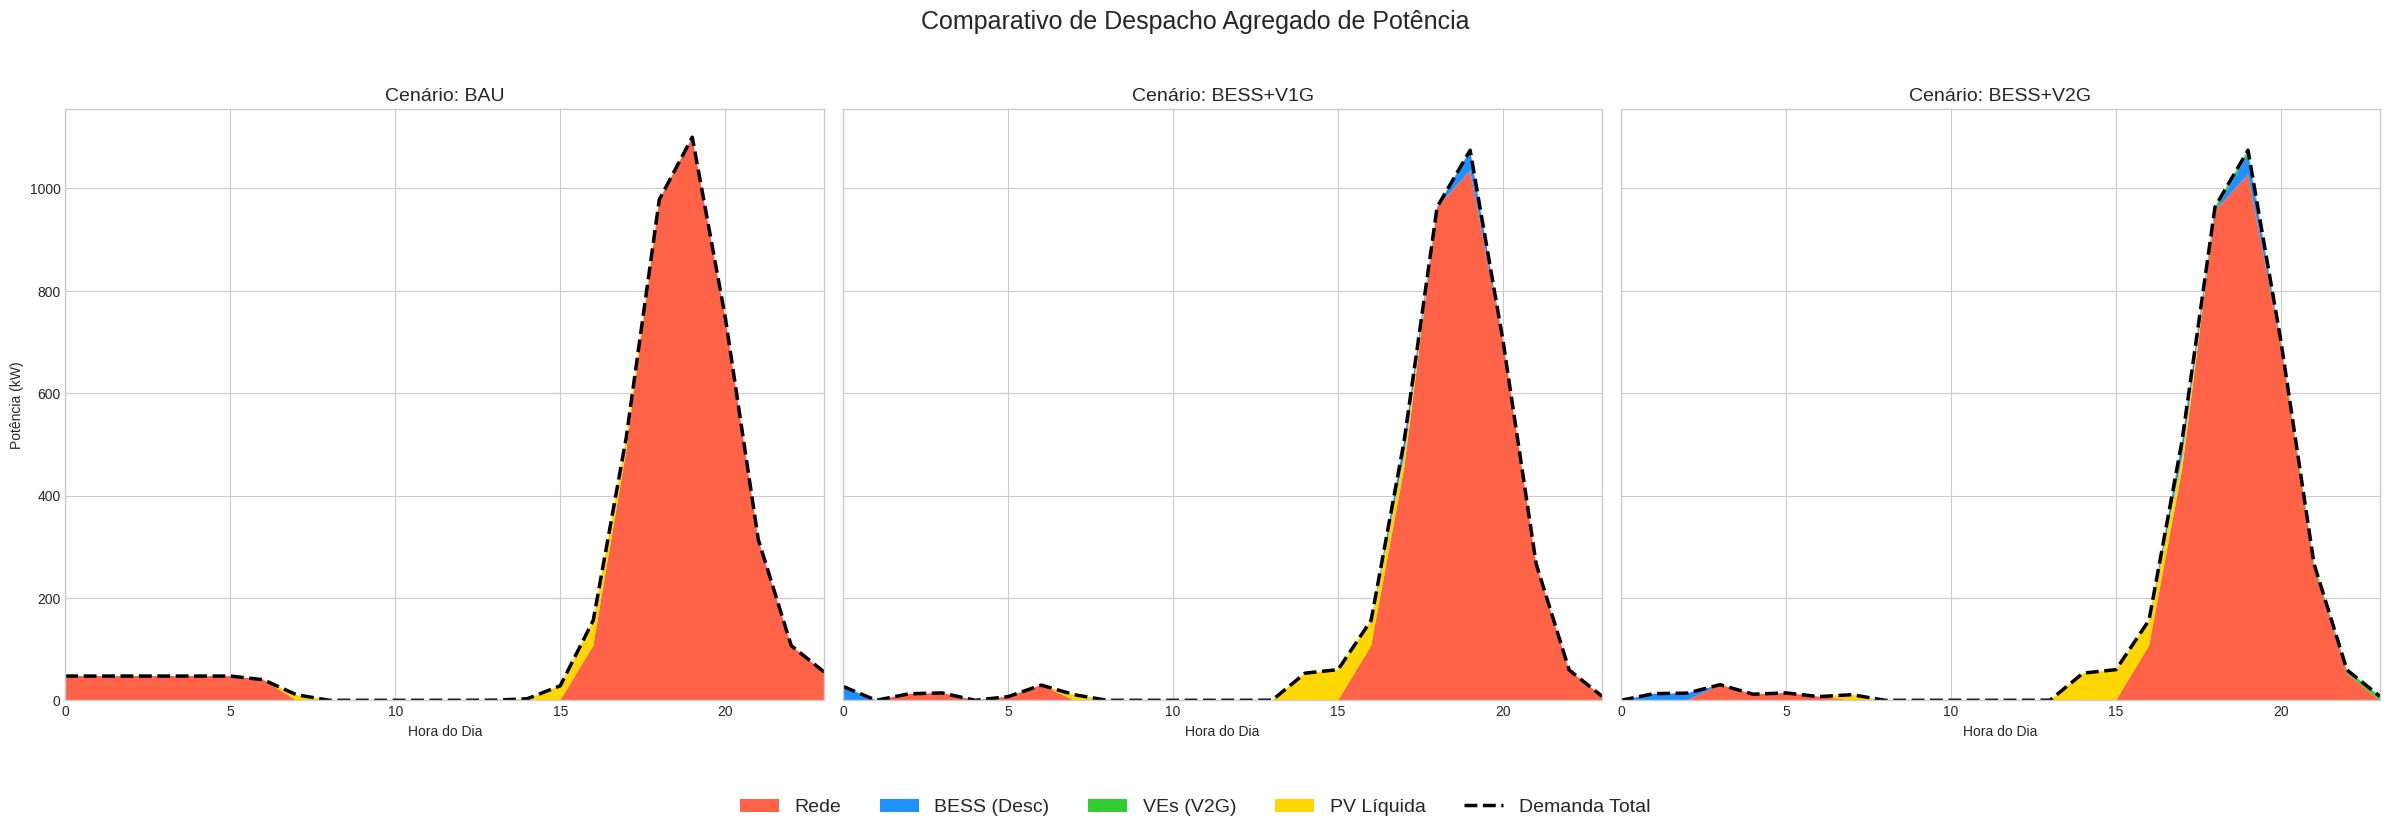

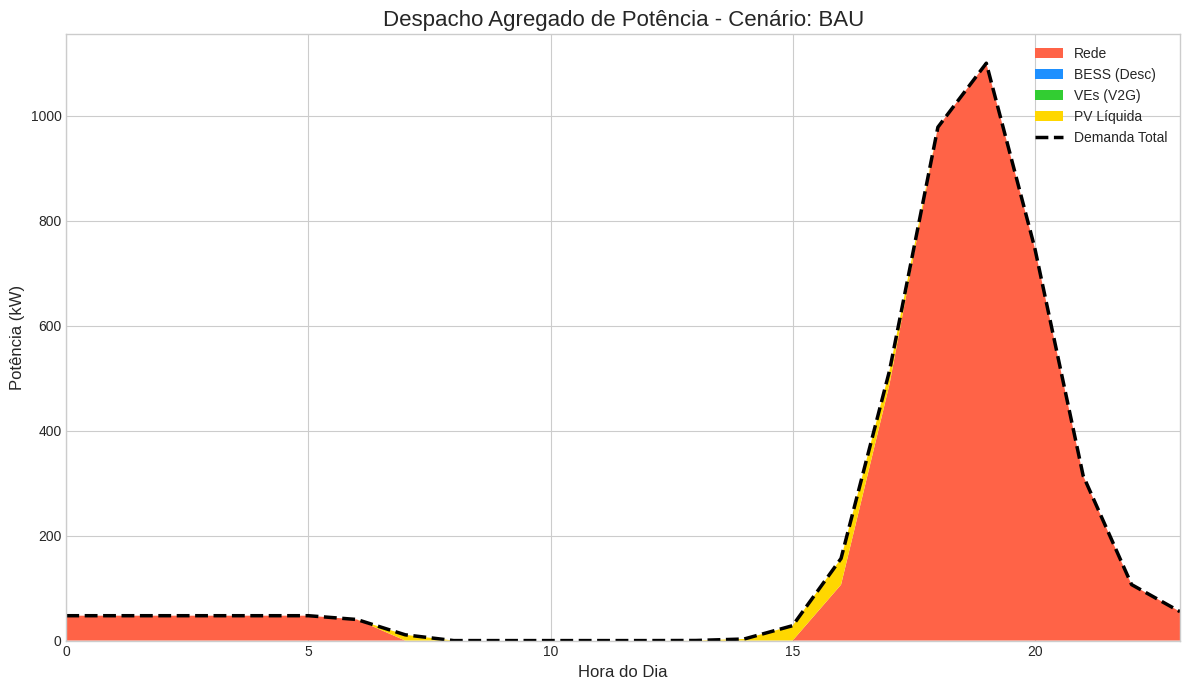

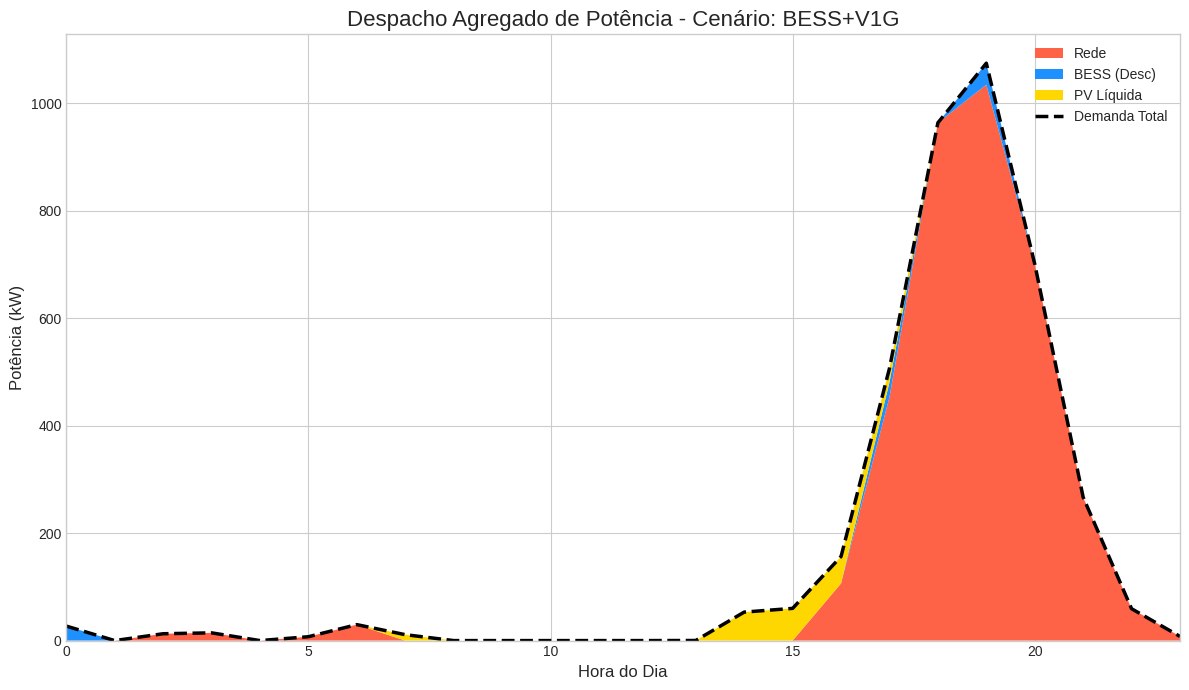

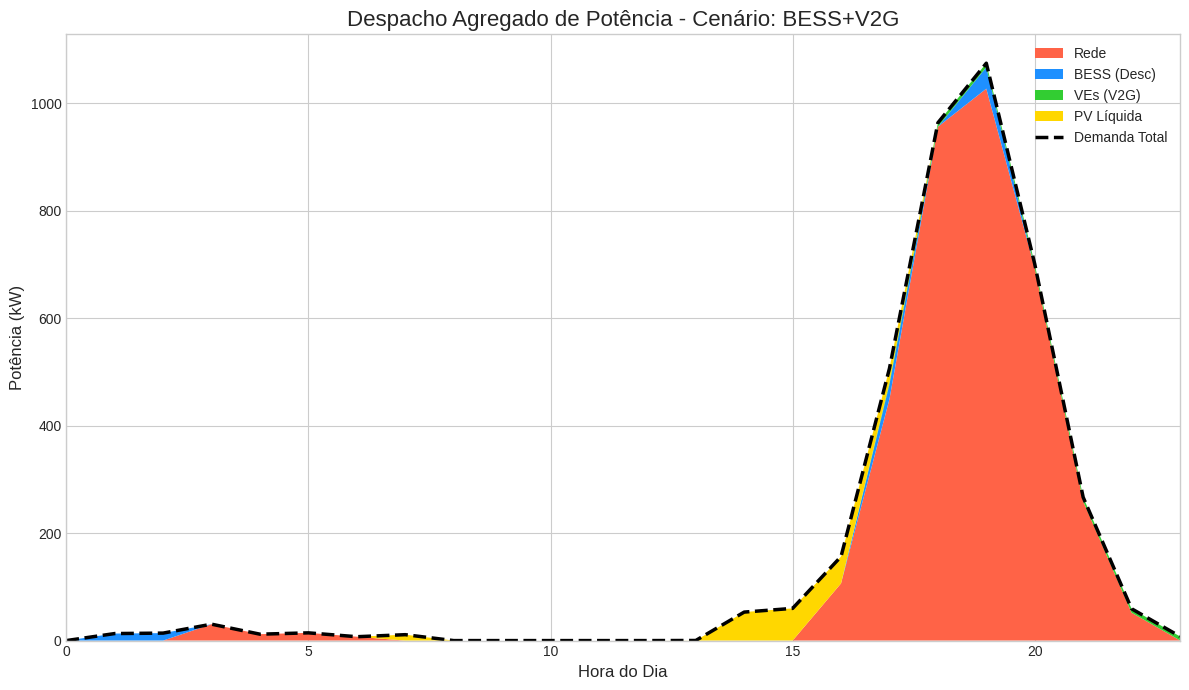

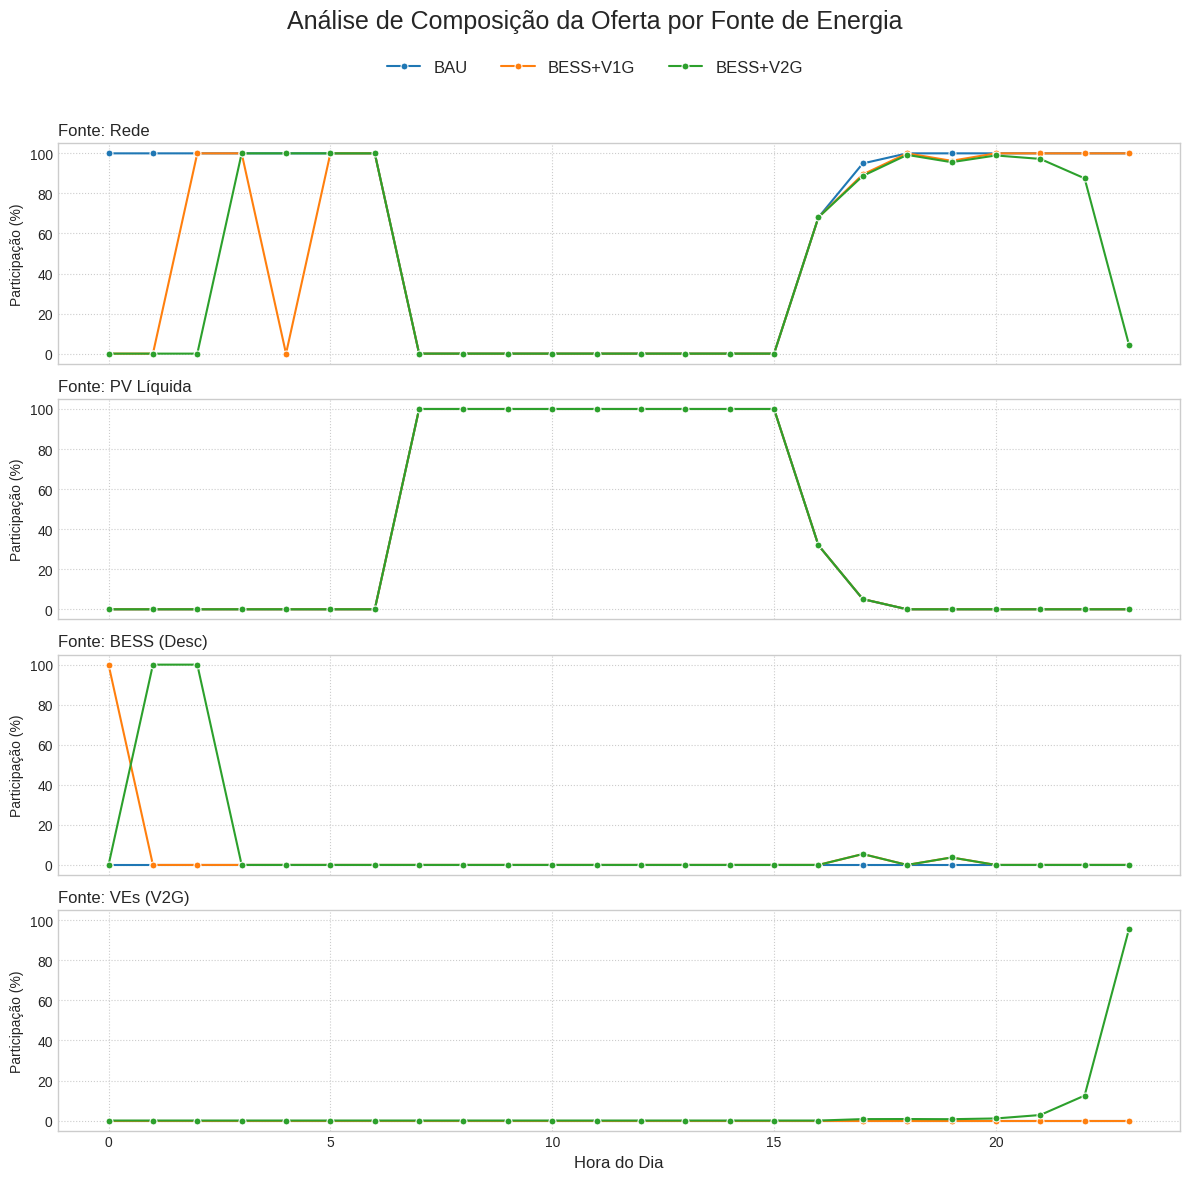

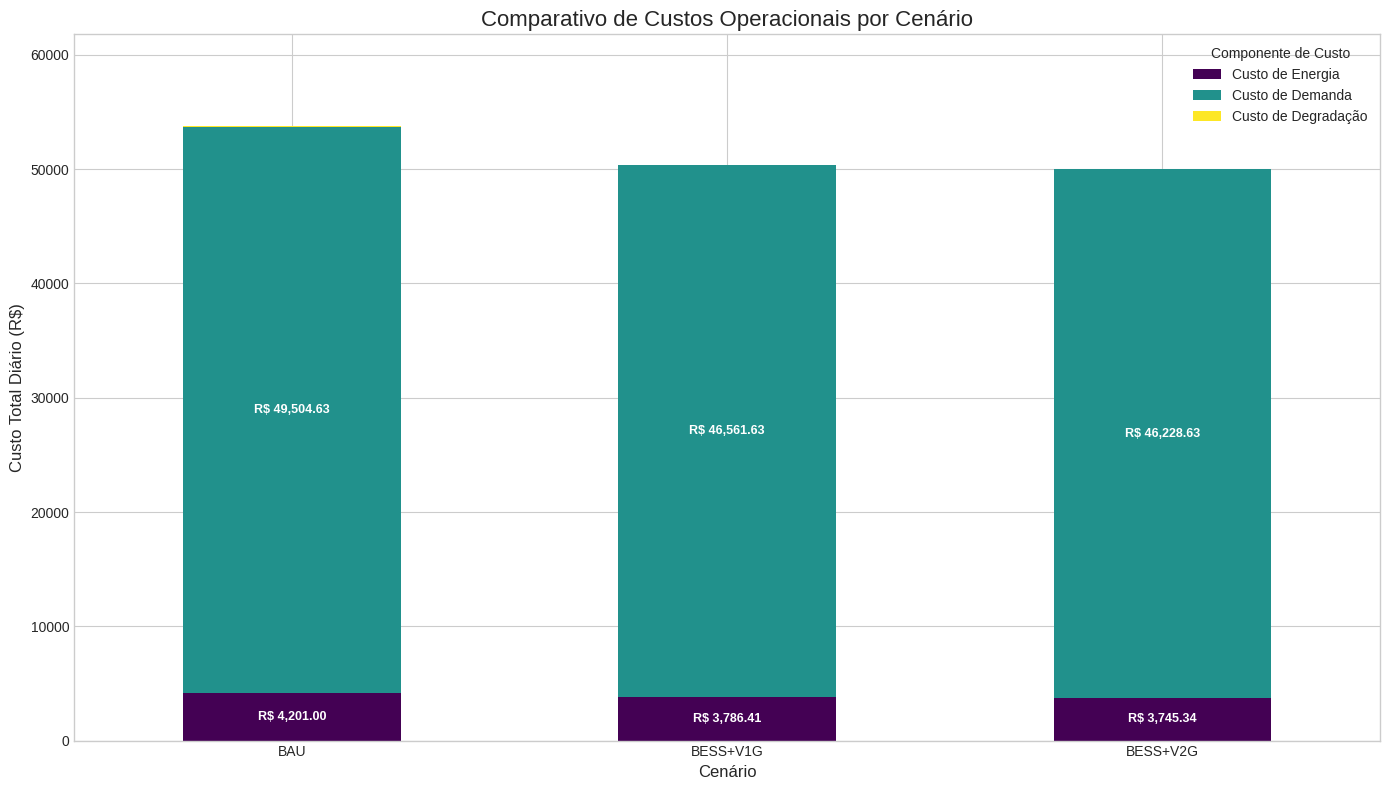

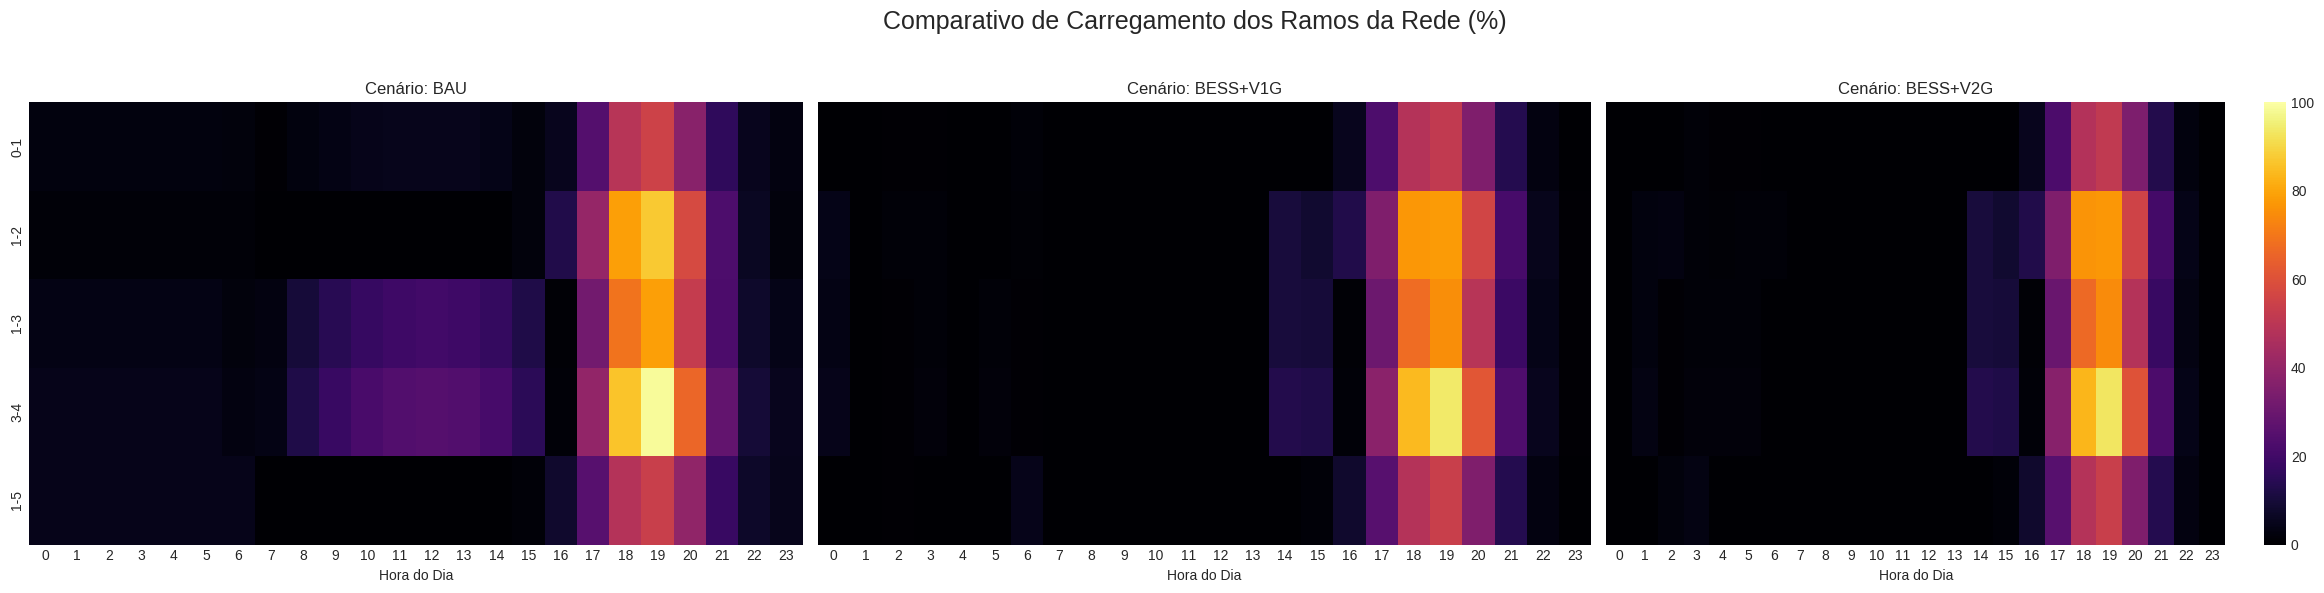

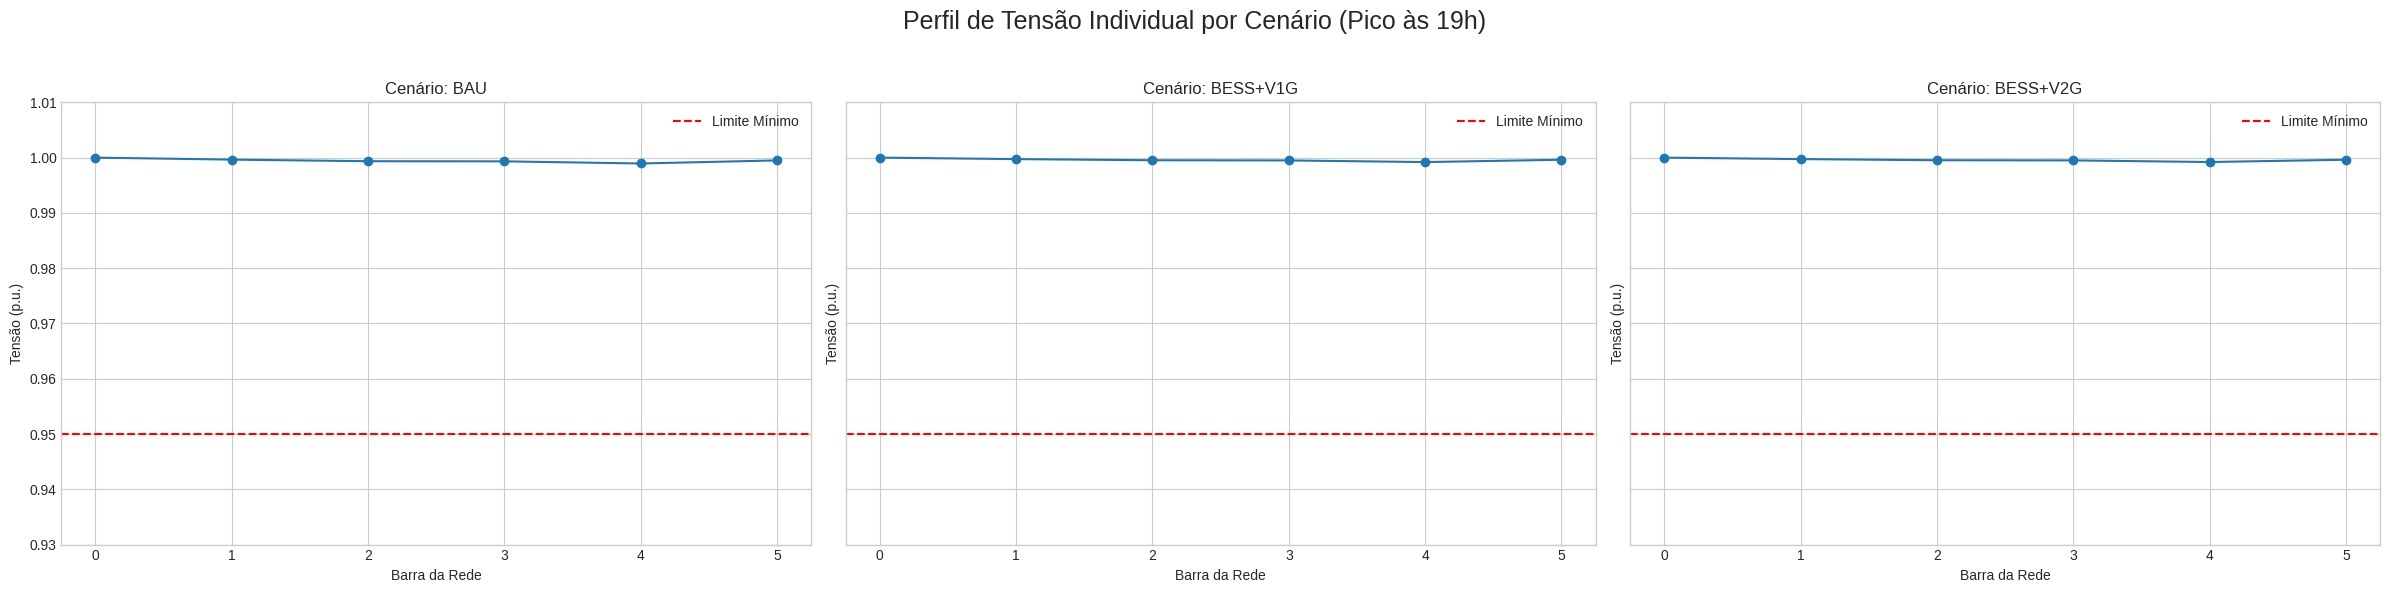

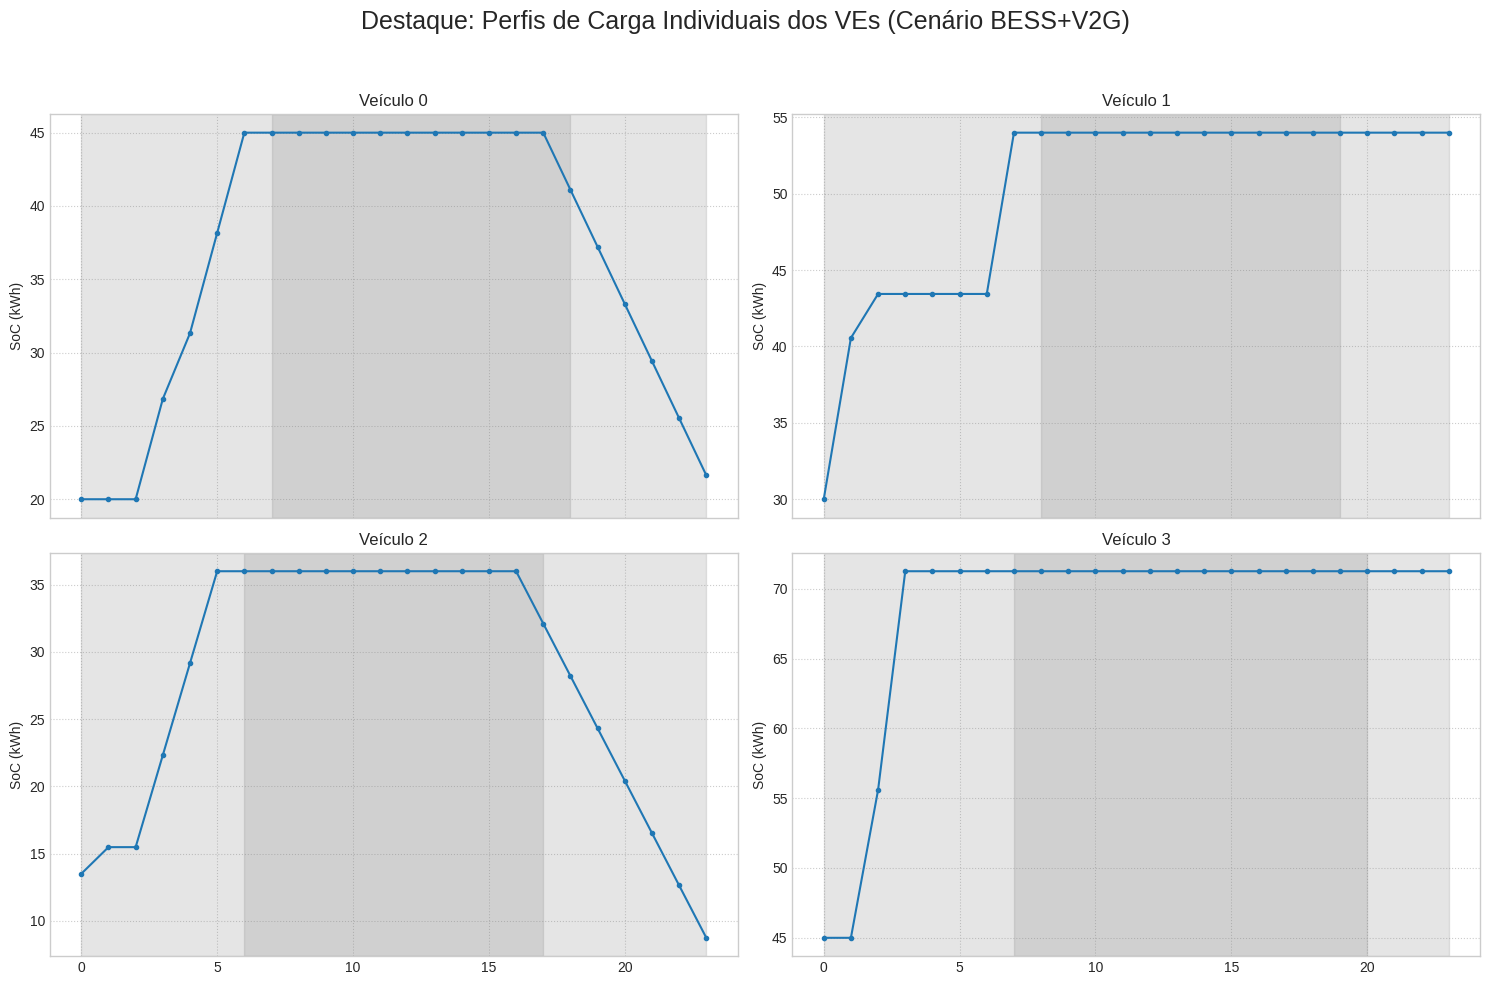


>>> ETAPA 8: RESUMO FINAL COMPARATIVO DOS RESULTADOS
Tabela Comparativa de Indicadores de Desempenho (KPIs):


,Custo Total (R$),Custo de Energia (R$),Custo de Demanda (R$),Custo de Degradação (R$),Pico de Demanda (kW),Energia Importada (kWh),Energia PV Curtailada (kWh),Tensão Mínima (p.u.),Redução Custo Total (%),Redução Pico Demanda (%)
Cenário,,,,,,,,,,
BAU,"53,734.24","4,201.00","49,504.63",28.61,"1,100.10","4,221.71",641.03,1.00,0.00,0.00
BESS+V1G,"50,370.75","3,786.41","46,561.63",22.71,"1,034.70","3,657.07",559.51,1.00,6.26,5.94
BESS+V2G,"49,999.08","3,745.34","46,228.63",25.11,"1,027.30","3,608.97",559.51,1.00,6.95,6.62


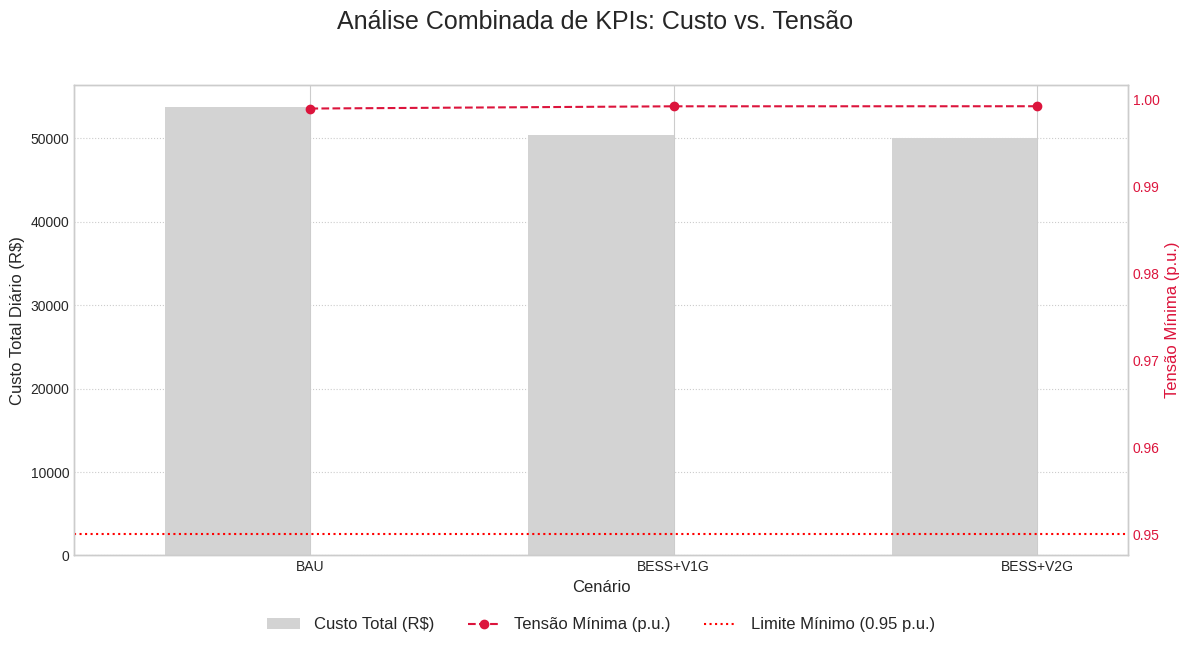

In [12]:
# Instalação da biblioteca Pyomo para modelagem de otimização
!pip install pyomo
# Instalação das bibliotecas padrão para manipulação de dados e visualização
!pip install pandas numpy matplotlib
# Comando para instalar o solver CBC usando o gerenciador de pacotes do Linux
!apt-get install -y -qq coinor-cbc
!apt-get update -qq
!apt-get install -y -qq glpk-utils
!pip install pyomo==6.7.1 seaborn==0.13.2 matplotlib==3.9.0 pandas==2.2.2

# Importação das bibliotecas necessárias
import pyomo.environ as pyo
import pandas as pd
import numpy as np
import os
from google.colab import drive
from IPython.display import display  # <- garante o display

print("Bibliotecas e solver instalados com sucesso.")
drive.mount('/content/drive')
path_to_data = '/content/drive/MyDrive/TCC_DATA_FILES/'

# --- (Opcional) Carregar dados de entrada do Drive, se você já tiver seus CSVs reais:
# general_params = pd.read_csv(path_to_data + 'general_parameters.csv', sep=',')
# load_profiles = pd.read_csv(path_to_data + 'load_profiles.csv', sep=',')
# pv_profiles = pd.read_csv(path_to_data + 'pv_profiles.csv', sep=',')
# ev_params = pd.read_csv(path_to_data + 'ev_parameters.csv', sep=',')
# tariffs = pd.read_csv(path_to_data + 'energy_tariffs.csv', sep=',')
# network_params = pd.read_csv(path_to_data + 'network_parameters.csv', sep=',')

print("Arquivos (locais/drive) prontos!")
import shutil
print("cbc path:", shutil.which("cbc"))
print("glpsol path:", shutil.which("glpsol"))

# -*- coding: utf-8 -*-
"""
======================================================================================================
SCRIPT DE OTIMIZAÇÃO E ANÁLISE VISUAL DE CENÁRIOS (VERSÃO TCC + Q em LinDistFlow)
======================================================================================================
Alterações principais (patch Q):
- Variáveis reativas: Q_grid[t], Q_ramo[i,j,t]
- Balanço de reativo por nó e hora (carga com PF; DERs com Q=0 por padrão)
- Queda de tensão LinDistFlow com R*P + X*Q (p.u.)
- Limites lineares para P e Q por ramo
- Suporte a X via coluna 'reactance_ohm' ou estimativa X/R padrão

Compatível com CBC. Mantém seus gráficos e KPIs.
======================================================================================================
"""

# ####################################################################################################
# ETAPA 1: CONFIGURAÇÃO DO AMBIENTE E DEPENDÊNCIAS
# ####################################################################################################
print(">>> ETAPA 1: Configurando o ambiente...")
try:
    import pyomo.environ as pyo
except ImportError:
    # Colab-only helpers
    !pip install -q pyomo
    !apt-get -y -qq install coinor-cbc

import pandas as pd
import pyomo.environ as pyo
import matplotlib.pyplot as plt
import numpy as np
import io
import seaborn as sns
from IPython.display import display

print("Ambiente configurado com sucesso.")

# ####################################################################################################
# ETAPA 2: DADOS DE ENTRADA E PRÉ-PROCESSAMENTO (exemplo gerado; troque pelos seus CSVs se quiser)
# ####################################################################################################
print("\n>>> ETAPA 2: Gerando e carregando arquivos de dados...")

# Parâmetros principais (exemplo)
fator_de_escala_da_carga = 5.0
print(f"AVISO: A carga da rede foi multiplicada por {fator_de_escala_da_carga}x para fins de visualização.")

# Inclui pf_carga (0,95 indutivo) e um X/R padrão (0,8) para quando não houver reactance_ohm
general_params_csv = """parametro,valor,unidade
capacidade_bess_kwh,100,kWh
pot_max_carga_bess_kw,50,kW
pot_max_descarga_bess_kw,40,kW
eficiencia_carga_bess,0.92,-
eficiencia_descarga_bess,0.90,-
soc_min_bess_pu,0.20,p.u.
soc_max_bess_pu,0.95,p.u.
soc_inicial_bess_pu,0.50,p.u.
custo_degradacao_bess_r_kwh,0.10,R$/kWh
custo_degradacao_ve_r_kwh,0.05,R$/kWh
custo_curtailment_pv_r_kwh,0.02,R$/kWh
custo_demanda_pico_r_kw,45.0,R$/kW
delta_t_h,1.0,h
v_base_kv,13.8,kV
s_base_mva,1.0,MVA
v_min_pu,0.95,p.u.
v_max_pu,1.05,p.u.
pf_carga,0.95,cosphi
x_over_r_default,0.80,ratio
""".strip()

tariffs_csv = """hora,tarifa_r_kwh
0,0.60
1,0.60
2,0.60
3,0.60
4,0.60
5,0.60
6,0.60
7,0.75
8,0.75
9,0.75
10,0.75
11,0.75
12,0.75
13,0.75
14,0.75
15,0.75
16,0.75
17,1.20
18,1.20
19,1.20
20,0.75
21,0.60
22,0.60
23,0.60
""".strip()

# Perfis (exemplo)
t_range = np.arange(24)
base_load = 40 + 30 * np.sin(np.pi * (t_range - 8) / 12)
peak_load = 1.8 * np.exp(-((t_range - 19)**2) / 4)
total_load_profile = base_load * peak_load * 2.5 * fator_de_escala_da_carga

load_profiles_df_gen = pd.DataFrame({'hora': t_range})
load_profiles_df_gen['load_kw_2'] = total_load_profile * 0.4
load_profiles_df_gen['load_kw_4'] = total_load_profile * 0.35
load_profiles_df_gen['load_kw_5'] = total_load_profile * 0.25
load_profiles_csv = load_profiles_df_gen.to_csv(index=False)

pv_profile = 100 * np.maximum(0, np.sin(np.pi * (t_range - 6) / 12))
pv_profiles_df_gen = pd.DataFrame({'hora': t_range, 'pv_kw_4': pv_profile})
pv_profiles_csv = pv_profiles_df_gen.to_csv(index=False)

ev_params_csv = """ve_id,capacidade_kwh,p_max_carga_kw,p_max_descarga_kw,ef_carga,ef_descarga,soc_inicial_pu,soc_alvo_pu,t_chegada,t_partida,aceita_v2g_b
0,50,7.2,3.7,0.95,0.95,0.40,0.9,18,7,1
1,60,11.0,5.0,0.96,0.94,0.50,0.9,19,8,0
2,45,7.2,3.7,0.95,0.95,0.30,0.8,17,6,1
3,75,22.0,11.0,0.97,0.96,0.60,0.95,20,7,0
""".strip()

# Rede: se não houver reactance_ohm na sua base real, usa o X/R padrão
network_params_csv = """from_node,to_node,resistance_ohm,p_max_kw
0,1,0.05,2000
1,2,0.10,500
1,3,0.12,500
3,4,0.15,400
1,5,0.08,500
""".strip()

# Leitura a partir dos CSVs gerados (troque por leitura do Drive se desejar)
general_df = pd.read_csv(io.StringIO(general_params_csv)).set_index('parametro')
tariffs_df = pd.read_csv(io.StringIO(tariffs_csv))
load_profiles_df = pd.read_csv(io.StringIO(load_profiles_csv))
pv_profiles_df = pd.read_csv(io.StringIO(pv_profiles_csv))
ev_parameters_df = pd.read_csv(io.StringIO(ev_params_csv))
network_parameters_df = pd.read_csv(io.StringIO(network_params_csv))

# Conjuntos
T = sorted([int(h) for h in tariffs_df['hora'].unique()])
T_list = list(T)
N_nodes = sorted([int(n) for n in pd.unique(network_parameters_df[['from_node', 'to_node']].values.ravel('K'))])
V = sorted([int(v) for v in ev_parameters_df['ve_id'].unique()])
E_branches = [tuple(int(x) for x in row) for row in network_parameters_df[['from_node', 'to_node']].values]

children_of = {n: [j for i, j in E_branches if i == n] for n in N_nodes}
parent_of = {j: i for i, j in E_branches}

# Parâmetros numéricos
params = {}
params['delta_t'] = float(general_df.loc['delta_t_h', 'valor'])
params['V_base_kv'] = float(general_df.loc['v_base_kv', 'valor'])
params['S_base_mva'] = float(general_df.loc['s_base_mva', 'valor'])
params['S_base_kw'] = params['S_base_mva'] * 1000.0
params['Z_base_ohm'] = (params['V_base_kv']**2) / params['S_base_mva']  # 3φ simplificado

params['C_pico'] = float(general_df.loc['custo_demanda_pico_r_kw', 'valor'])
params['C_curt'] = float(general_df.loc['custo_curtailment_pv_r_kwh', 'valor'])
params['C_deg_BESS'] = float(general_df.loc['custo_degradacao_bess_r_kwh', 'valor'])
params['C_deg_VE'] = float(general_df.loc['custo_degradacao_ve_r_kwh', 'valor'])

params['SoC_min_BESS_pu'] = float(general_df.loc['soc_min_bess_pu', 'valor'])
params['SoC_max_BESS_pu'] = float(general_df.loc['soc_max_bess_pu', 'valor'])
params['SoC_init_BESS_pu'] = float(general_df.loc['soc_inicial_bess_pu', 'valor'])

params['Pmax_ch_BESS_kw'] = float(general_df.loc['pot_max_carga_bess_kw', 'valor'])
params['Pmax_dis_BESS_kw'] = float(general_df.loc['pot_max_descarga_bess_kw', 'valor'])
params['eta_ch_BESS'] = float(general_df.loc['eficiencia_carga_bess', 'valor'])
params['eta_dis_BESS'] = float(general_df.loc['eficiencia_descarga_bess', 'valor'])

params['C_energia'] = tariffs_df.set_index('hora')['tarifa_r_kwh'].astype(float).to_dict()

# Cargas ativas P_carga(j,t)
params['P_carga'] = {}
for t in T:
    for col in load_profiles_df.columns:
        if col.startswith('load_kw_'):
            j = int(col.split('_')[-1])
            vals = load_profiles_df.loc[load_profiles_df['hora'] == t, col].values
            params['P_carga'][(j, t)] = float(vals[0]) if len(vals) > 0 else 0.0

# PV (assumido PF ~ 1 -> Q_pv = 0)
params['P_pv'] = {}
for t in T:
    for col in pv_profiles_df.columns:
        if col.startswith('pv_kw_'):
            j = int(col.split('_')[-1])
            vals = pv_profiles_df.loc[pv_profiles_df['hora'] == t, col].values
            params['P_pv'][(j, t)] = float(vals[0]) if len(vals) > 0 else 0.0

# VEs
ev_map = ev_parameters_df.set_index('ve_id').to_dict('index')
params['Emax_VE'] = {i: float(ev_map[i]['capacidade_kwh']) for i in V}
params['Pmax_ch_VE'] = {i: float(ev_map[i]['p_max_carga_kw']) for i in V}
params['Pmax_dis_VE'] = {i: float(ev_map[i]['p_max_descarga_kw']) for i in V}
params['eta_ch_VE'] = {i: float(ev_map[i]['ef_carga']) for i in V}
params['eta_dis_VE'] = {i: float(ev_map[i]['ef_descarga']) for i in V}
params['SoC_init_VE_kwh'] = {i: float(ev_map[i]['soc_inicial_pu']) * float(ev_map[i]['capacidade_kwh']) for i in V}
params['SoC_target_VE_kwh'] = {i: float(ev_map[i]['soc_alvo_pu']) * float(ev_map[i]['capacidade_kwh']) for i in V}
params['t_chegada_VE'] = {i: int(ev_map[i]['t_chegada']) for i in V}
params['t_partida_VE'] = {i: int(ev_map[i]['t_partida']) for i in V}
params['b_v2g_VE'] = {i: int(ev_map[i]['aceita_v2g_b']) for i in V}

# Disponibilidade dos VEs
params['a_disp_VE'] = {}
for i in V:
    chegada, partida = params['t_chegada_VE'][i], params['t_partida_VE'][i]
    for t in T:
        if chegada > partida:
            params['a_disp_VE'][(i, t)] = 1 if (t >= chegada or t < partida) else 0
        else:
            params['a_disp_VE'][(i, t)] = 1 if (chegada <= t < partida) else 0

# Rede: R e (opcional) X
R_ohm = {(int(r['from_node']), int(r['to_node'])): float(r['resistance_ohm']) for _, r in network_parameters_df.iterrows()}

# Se houver reactance_ohm, usa. Senão estima X = R * (X/R)_default
x_over_r_default = float(general_df.loc['x_over_r_default', 'valor'])
if 'reactance_ohm' in network_parameters_df.columns:
    X_ohm = {(int(r['from_node']), int(r['to_node'])): float(r['reactance_ohm']) for _, r in network_parameters_df.iterrows()}
else:
    X_ohm = {k: v * x_over_r_default for k, v in R_ohm.items()}

params['R_pu'] = {k: v / params['Z_base_ohm'] for k, v in R_ohm.items()}
params['X_pu'] = {k: v / params['Z_base_ohm'] for k, v in X_ohm.items()}

# Limite de ramo (tratado como S_max linear para P e Q)
params['S_max_ramo_kw'] = {(int(r['from_node']), int(r['to_node'])): float(r['p_max_kw']) for _, r in network_parameters_df.iterrows()}

# Local dos recursos
params['BESS_node'] = 2
params['VE_nodes'] = {0: 2, 1: 4, 2: 4, 3: 5}

# Índices de tempo anteriores (SOE)
t_prev_map = {tt: T_list[idx - 1] if idx > 0 else T_list[-1] for idx, tt in enumerate(T_list)}

# NOVO: Q de carga a partir de PF
pf_carga = float(general_df.loc['pf_carga', 'valor'])
phi = np.arccos(np.clip(pf_carga, -1.0, 1.0))
tanphi = np.tan(phi)
params['Q_carga'] = {(j, t): params['P_carga'].get((j, t), 0.0) * tanphi for j in N_nodes for t in T_list}

print("Pré-processamento concluído.")

# ####################################################################################################
# ETAPA 3: FUNÇÕES DE SIMULAÇÃO E OTIMIZAÇÃO
# ####################################################################################################
def run_optimization_scenario(params, v2g_enabled, bess_present):
    print(f"\n>>> Executando Otimização: V2G {'Habilitado' if v2g_enabled else 'Desabilitado'}, BESS {'Presente' if bess_present else 'Ausente'}")
    m = pyo.ConcreteModel()

    # Conjuntos
    m.T = pyo.Set(initialize=T)
    m.N = pyo.Set(initialize=N_nodes)
    m.VE = pyo.Set(initialize=V)
    m.E = pyo.Set(initialize=E_branches, dimen=2)

    # Variáveis de potência ativa existentes
    m.P_grid = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_max_pico = pyo.Var(domain=pyo.NonNegativeReals)
    m.P_curt = pyo.Var(m.N, m.T, domain=pyo.NonNegativeReals)

    m.P_bess_ch = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_bess_dis = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.SoC_BESS = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.u_BESS = pyo.Var(m.T, domain=pyo.Binary)

    m.P_ve_ch = pyo.Var(m.VE, m.T, domain=pyo.NonNegativeReals)
    m.P_ve_dis = pyo.Var(m.VE, m.T, domain=pyo.NonNegativeReals)
    m.SoC_VE = pyo.Var(m.VE, m.T, domain=pyo.NonNegativeReals)
    m.u_VE = pyo.Var(m.VE, m.T, domain=pyo.Binary)

    m.P_ramo = pyo.Var(m.E, m.T, domain=pyo.Reals)

    # NOVO: variáveis reativas
    m.Q_grid = pyo.Var(m.T, domain=pyo.Reals)
    m.Q_ramo = pyo.Var(m.E, m.T, domain=pyo.Reals)

    # Tensão (quadrado) por nó/hora
    m.V2_no = pyo.Var(m.N, m.T, domain=pyo.NonNegativeReals)

    # Objetivo
    def objective_rule(m):
        custo_energia = sum(params['C_energia'][t] * m.P_grid[t] * params['delta_t'] for t in m.T)
        custo_pico = params['C_pico'] * m.P_max_pico
        custo_curt = sum(params['C_curt'] * m.P_curt[j, t] * params['delta_t'] for j in m.N for t in m.T)
        custo_deg_bess = sum(params['C_deg_BESS'] * (m.P_bess_ch[t] + m.P_bess_dis[t]) * params['delta_t'] for t in m.T if bess_present)
        custo_deg_ve = sum(params['C_deg_VE'] * (m.P_ve_ch[i, t] + m.P_ve_dis[i, t]) * params['delta_t'] for i in m.VE for t in m.T)
        return custo_energia + custo_pico + custo_curt + custo_deg_bess + custo_deg_ve
    m.objective = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

    # Pico
    m.peak_demand_constraint = pyo.Constraint(m.T, rule=lambda m, t: m.P_grid[t] <= m.P_max_pico)

    # Curtailment não pode exceder PV
    m.curtailment_limit_constraint = pyo.Constraint(m.N, m.T, rule=lambda m, j, t: m.P_curt[j, t] <= params['P_pv'].get((j, t), 0.0))

    # BESS
    if bess_present:
        Emax_BESS_kwh = float(general_df.loc['capacidade_bess_kwh', 'valor'])
        SoC_min_BESS_kwh = params['SoC_min_BESS_pu'] * Emax_BESS_kwh
        SoC_max_BESS_kwh = params['SoC_max_BESS_pu'] * Emax_BESS_kwh
        SoC_init_BESS_kwh = params['SoC_init_BESS_pu'] * Emax_BESS_kwh

        def bess_soc_rule(m, t):
            t_prev = t_prev_map[t]
            soc_prev = SoC_init_BESS_kwh if t == T_list[0] else m.SoC_BESS[t_prev]
            return m.SoC_BESS[t] == soc_prev + (m.P_bess_ch[t] * params['eta_ch_BESS'] - m.P_bess_dis[t] / params['eta_dis_BESS']) * params['delta_t']
        m.bess_soc_constraint = pyo.Constraint(m.T, rule=bess_soc_rule)

        m.bess_soc_limits_constraint = pyo.Constraint(m.T, rule=lambda m, t: pyo.inequality(SoC_min_BESS_kwh, m.SoC_BESS[t], SoC_max_BESS_kwh))
        m.bess_charge_limit_constraint = pyo.Constraint(m.T, rule=lambda m, t: m.P_bess_ch[t] <= params['Pmax_ch_BESS_kw'] * m.u_BESS[t])
        m.bess_discharge_limit_constraint = pyo.Constraint(m.T, rule=lambda m, t: m.P_bess_dis[t] <= params['Pmax_dis_BESS_kw'] * (1 - m.u_BESS[t]))
    else:
        m.bess_zero_power = pyo.Constraint(m.T, rule=lambda m, t: (m.P_bess_ch[t] == 0) & (m.P_bess_dis[t] == 0))

    # VEs (SoC)
    def ve_soc_rule(m, i, t):
        t_prev = t_prev_map[t]
        soc_prev = params['SoC_init_VE_kwh'][i] if t == T_list[0] else m.SoC_VE[i, t_prev]
        return m.SoC_VE[i, t] == soc_prev + (m.P_ve_ch[i, t] * params['eta_ch_VE'][i] - m.P_ve_dis[i, t] / params['eta_dis_VE'][i]) * params['delta_t']
    m.ve_soc_constraint = pyo.Constraint(m.VE, m.T, rule=ve_soc_rule)

    m.ve_charge_limit_constraint = pyo.Constraint(m.VE, m.T, rule=lambda m, i, t: m.P_ve_ch[i, t] <= params['Pmax_ch_VE'][i] * params['a_disp_VE'][(i, t)] * m.u_VE[i, t])
    m.ve_discharge_limit_constraint = pyo.Constraint(m.VE, m.T, rule=lambda m, i, t: m.P_ve_dis[i, t] <= params['Pmax_dis_VE'][i] * params['a_disp_VE'][(i, t)] * (params['b_v2g_VE'][i] if v2g_enabled else 0) * (1 - m.u_VE[i, t]))

    # Meta de SoC na partida
    def ve_soc_target_rule(m, i):
        t_partida = params['t_partida_VE'][i]
        t_idx = t_partida - 1 if t_partida > 0 else T_list[-1]
        return m.SoC_VE[i, t_idx] >= params['SoC_target_VE_kwh'][i]
    m.ve_soc_target_constraint = pyo.Constraint(m.VE, rule=ve_soc_target_rule)

    # Balanço nodal de POTÊNCIA ATIVA (P)
    def nodal_P_balance(m, j, t):
        if j == 0:
            return m.P_grid[t] == sum(m.P_ramo[0, k, t] for (jf, k) in m.E if jf == 0)
        parent_n = parent_of.get(j, None)
        if parent_n is None:
            return pyo.Constraint.Skip
        fluxo_entrada = m.P_ramo[parent_n, j, t]
        fluxo_saida = sum(m.P_ramo[j, k, t] for k in children_of.get(j, []))
        inj_pv = params['P_pv'].get((j, t), 0.0) - m.P_curt[j, t]
        inj_bess = (m.P_bess_dis[t] - m.P_bess_ch[t]) if (j == params['BESS_node'] and bess_present) else 0.0
        inj_ves = sum(m.P_ve_dis[i, t] - m.P_ve_ch[i, t] for i in m.VE if params['VE_nodes'].get(i, None) == j)
        carga = params['P_carga'].get((j, t), 0.0)
        return fluxo_entrada - fluxo_saida == carga - (inj_pv + inj_bess + inj_ves)
    m.nodal_power_balance_constraint = pyo.Constraint(m.N, m.T, rule=nodal_P_balance)

    # NOVO: Balanço nodal de POTÊNCIA REATIVA (Q)
    def nodal_Q_balance(m, j, t):
        if j == 0:
            return m.Q_grid[t] == sum(m.Q_ramo[0, k, t] for (jf, k) in m.E if jf == 0)
        parent_n = parent_of.get(j, None)
        if parent_n is None:
            return pyo.Constraint.Skip
        fluxo_entrada = m.Q_ramo[parent_n, j, t]
        fluxo_saida = sum(m.Q_ramo[j, k, t] for k in children_of.get(j, []))
        inj_Q_der = 0.0  # DERs com Q=0 por padrão
        q_carga = params['Q_carga'][(j, t)]
        return fluxo_entrada - fluxo_saida == q_carga - inj_Q_der
    m.nodal_reactive_balance_constraint = pyo.Constraint(m.N, m.T, rule=nodal_Q_balance)

    # Queda de tensão LinDistFlow (p.u.) com R*P + X*Q
    @m.Constraint(m.E, m.T)
    def voltage_drop_constraint(m, i, j, t):
        p_pu = m.P_ramo[i, j, t] / params['S_base_kw']
        q_pu = m.Q_ramo[i, j, t] / params['S_base_kw']
        return m.V2_no[j, t] == m.V2_no[i, t] - 2.0 * (params['R_pu'][(i, j)] * p_pu + params['X_pu'][(i, j)] * q_pu)

    # Slack V^2 = 1.0
    m.slack_bus_voltage_constraint = pyo.Constraint(m.T, rule=lambda m, t: m.V2_no[0, t] == 1.0**2)

    # Limites de tensão
    V_min_sq = float(general_df.loc['v_min_pu', 'valor'])**2
    V_max_sq = float(general_df.loc['v_max_pu', 'valor'])**2
    m.voltage_limits_constraint = pyo.Constraint(m.N, m.T, rule=lambda m, j, t: pyo.inequality(V_min_sq, m.V2_no[j, t], V_max_sq))

    # Limites lineares de ramo (box) para P e Q
    m.branch_P_limits = pyo.Constraint(m.E, m.T, rule=lambda m, i, j, t: pyo.inequality(-params['S_max_ramo_kw'][(i, j)], m.P_ramo[i, j, t], params['S_max_ramo_kw'][(i, j)]))
    m.branch_Q_limits = pyo.Constraint(m.E, m.T, rule=lambda m, i, j, t: pyo.inequality(-params['S_max_ramo_kw'][(i, j)], m.Q_ramo[i, j, t], params['S_max_ramo_kw'][(i, j)]))

    # Solver
    solver = pyo.SolverFactory('cbc')
    results = solver.solve(m, tee=False)

    if (results.solver.status == pyo.SolverStatus.ok) and (results.solver.termination_condition == pyo.TerminationCondition.optimal):
        print("Solução ótima encontrada!")
        return results, m
    else:
        print("Atenção: solução não ótima.")
        return results, m

def simulate_bau_scenario(params):
    """Cenário BAU (sem otimização): mantido e estendido para registrar V e fluxos com Q."""
    print("\n>>> Simulando Cenário Base (BAU)...")
    df = pd.DataFrame(index=T_list); df.index.name = 'hora'

    # Carga de VE "pior caso": máximo quando presente
    p_ve_ch_nodal = {(j, t): 0.0 for j in N_nodes for t in T_list}
    for i in V:
        ve_node = params['VE_nodes'][i]
        for t in T_list:
            if params['a_disp_VE'][(i, t)] == 1:
                p_ve_ch_nodal[ve_node, t] += params['Pmax_ch_VE'][i]

    # Injeção líquida nodal ativa
    p_inj_nodal = {(j, t): params['P_pv'].get((j, t), 0.0) - params['P_carga'].get((j, t), 0.0) - p_ve_ch_nodal.get((j, t), 0.0)
                   for j in N_nodes for t in T_list}

    # Fluxos aproximados radial — P e Q
    p_ramo, q_ramo, v2 = {}, {}, {}
    for t in T_list:
        p_fluxo_nodal = {j: -p_inj_nodal[j, t] for j in N_nodes}
        q_fluxo_nodal = {j: params['Q_carga'][(j, t)] for j in N_nodes}

        for j in sorted(N_nodes, reverse=True):
            if j != 0:
                p_ramo[parent_of[j], j, t] = p_fluxo_nodal[j] + sum(p_ramo.get((j, k, t), 0.0) for k in children_of.get(j, []))
                q_ramo[parent_of[j], j, t] = q_fluxo_nodal[j] + sum(q_ramo.get((j, k, t), 0.0) for k in children_of.get(j, []))

        # Queda de tensão (forward)
        v2[0, t] = 1.0
        nodes_to_process = list(children_of.get(0, []))
        head = 0
        while head < len(nodes_to_process):
            j = nodes_to_process[head]
            i = parent_of[j]
            p_pu = (p_ramo.get((i, j, t), 0.0)) / params['S_base_kw']
            q_pu = (q_ramo.get((i, j, t), 0.0)) / params['S_base_kw']
            v2[j, t] = v2[(i, t)] - 2.0 * (params['R_pu'][(i, j)] * p_pu + params['X_pu'][(i, j)] * q_pu)
            nodes_to_process.extend(children_of.get(j, []))
            head += 1

    # Saídas principais BAU
    df['P_grid_kW'] = [sum(p_ramo.get((0, k, t), 0.0) for k in children_of.get(0, [])) for t in T_list]
    df['P_grid_kW'] = df['P_grid_kW'].clip(lower=0)
    df['P_carga_total_kW'] = [sum(params['P_carga'].get((j, t), 0.0) for j in N_nodes) for t in T_list]
    df['P_pv_total_kW'] = [sum(params['P_pv'].get((j, t), 0.0) for j in N_nodes) for t in T_list]
    df['P_ve_ch_total_kW'] = [sum(p_ve_ch_nodal.get((j, t), 0.0) for j in N_nodes) for t in T_list]
    df['P_ve_dis_total_kW'] = 0.0
    df['P_curt_total_kW'] = (df['P_pv_total_kW'] - (df['P_carga_total_kW'] + df['P_ve_ch_total_kW'] - df['P_grid_kW'])).clip(lower=0)

    df['P_bess_ch_kW'] = 0.0; df['P_bess_dis_kW'] = 0.0; df['SoC_BESS_kWh'] = 0.0
    for j in N_nodes:
        df[f'V_no_{j}_pu'] = [np.sqrt(max(v2.get((j, t), 1.0), 0.0)) for t in T_list]

    pico = df['P_grid_kW'].max()
    custo_energia = (df['P_grid_kW'] * pd.Series(params['C_energia']) * params['delta_t']).sum()
    custo_pico = params['C_pico'] * pico
    custo_degradacao = (df['P_ve_ch_total_kW'] * params['C_deg_VE'] * params['delta_t']).sum()
    kpis = {'Custo de Energia': custo_energia, 'Custo de Demanda': custo_pico, 'Custo de Degradação': custo_degradacao}

    detalhes = {}
    ramoP_df = pd.DataFrame(index=T_list, columns=[f'{i}-{j}' for i, j in E_branches])
    ramoQ_df = pd.DataFrame(index=T_list, columns=[f'{i}-{j}' for i, j in E_branches])
    for t in T_list:
        for i, j in E_branches:
            ramoP_df.loc[t, f'{i}-{j}'] = p_ramo.get((i, j, t), 0.0)
            ramoQ_df.loc[t, f'{i}-{j}'] = q_ramo.get((i, j, t), 0.0)
    detalhes['ramoP_df'] = ramoP_df
    detalhes['ramoQ_df'] = ramoQ_df

    return df, kpis, detalhes

# ####################################################################################################
# ETAPAS 4, 5 e 6: EXECUÇÃO, EXTRAÇÃO E PROCESSAMENTO
# ####################################################################################################
print("\n" + "="*80 + "\n>>> ETAPAS 4, 5, 6: EXECUTANDO CENÁRIOS E PROCESSANDO DADOS\n" + "="*80)
results_repo = {}

# BAU
results_repo['BAU'] = {}
results_repo['BAU']['agregado'], results_repo['BAU']['kpis'], results_repo['BAU']['detalhado'] = simulate_bau_scenario(params)

# Otimizados
scenarios_opt = {
    'BESS+V1G': {'v2g': False, 'bess': True},
    'BESS+V2G': {'v2g': True,  'bess': True}
}
for name, cfg in scenarios_opt.items():
    results, m = run_optimization_scenario(params, v2g_enabled=cfg['v2g'], bess_present=cfg['bess'])
    if m is None:
        continue
    results_repo[name] = {}
    agg = pd.DataFrame(index=T_list)
    agg['P_grid_kW'] = [pyo.value(m.P_grid[t]) for t in T_list]
    agg['P_carga_total_kW'] = [sum(params['P_carga'].get((j, t), 0.0) for j in N_nodes) for t in T_list]
    agg['P_pv_total_kW'] = [sum(params['P_pv'].get((j, t), 0.0) for j in N_nodes) for t in T_list]
    agg['P_curt_total_kW'] = [sum(pyo.value(m.P_curt[j, t]) for j in N_nodes) for t in T_list]
    agg['P_bess_ch_kW'] = [pyo.value(m.P_bess_ch[t]) for t in T_list]
    agg['P_bess_dis_kW'] = [pyo.value(m.P_bess_dis[t]) for t in T_list]
    agg['SoC_BESS_kWh'] = [pyo.value(m.SoC_BESS[t]) if cfg['bess'] else 0.0 for t in T_list]
    agg['P_ve_ch_total_kW'] = [sum(pyo.value(m.P_ve_ch[i, t]) for i in V) for t in T_list]
    agg['P_ve_dis_total_kW'] = [sum(pyo.value(m.P_ve_dis[i, t]) for i in V) for t in T_list]
    for j in N_nodes:
        agg[f'V_no_{j}_pu'] = [np.sqrt(max(pyo.value(m.V2_no[j, t]), 0.0)) for t in T_list]
    results_repo[name]['agregado'] = agg

    custos = {
        'Custo de Energia': sum(params['C_energia'][t] * pyo.value(m.P_grid[t]) * params['delta_t'] for t in T_list),
        'Custo de Demanda': params['C_pico'] * pyo.value(m.P_max_pico),
        'Custo de Degradação': pyo.value(
            sum(params['C_deg_BESS'] * (m.P_bess_ch[t] + m.P_bess_dis[t]) * params['delta_t'] for t in T_list if cfg['bess'])
            + sum(params['C_deg_VE'] * (m.P_ve_ch[i, t] + m.P_ve_dis[i, t]) * params['delta_t'] for i in V for t in T_list)
        )
    }
    results_repo[name]['kpis'] = custos

    det = {}
    soc_ve_df = pd.DataFrame({f'VE_{i}': [pyo.value(m.SoC_VE[i, t]) for t in T_list] for i in V}, index=T_list)
    det['soc_ve_df'] = soc_ve_df

    ramoP_df = pd.DataFrame(index=T_list, columns=[f'{i}-{j}' for i, j in E_branches])
    ramoQ_df = pd.DataFrame(index=T_list, columns=[f'{i}-{j}' for i, j in E_branches])
    for t in T_list:
        for i, j in E_branches:
            ramoP_df.loc[t, f'{i}-{j}'] = pyo.value(m.P_ramo[i, j, t])
            ramoQ_df.loc[t, f'{i}-{j}'] = pyo.value(m.Q_ramo[i, j, t])
    det['ramoP_df'] = ramoP_df
    det['ramoQ_df'] = ramoQ_df

    results_repo[name]['detalhado'] = det

print("Processamento de todos os cenários concluído.")

# ####################################################################################################
# ETAPA 7: VISUALIZAÇÕES
# ####################################################################################################
plt.style.use('seaborn-v0_8-whitegrid')

def plot_despacho_comparativo(results_repo):
    fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)
    fig.suptitle('Comparativo de Despacho Agregado de Potência', fontsize=18)

    scenarios_to_plot = ['BAU', 'BESS+V1G', 'BESS+V2G']
    legend_elements = {}

    for ax, scenario in zip(axes, scenarios_to_plot):
        df = results_repo[scenario]['agregado']
        pv_net = df['P_pv_total_kW'] - df['P_curt_total_kW']

        series_data = {'Rede': df['P_grid_kW'], 'PV Líquida': pv_net, 'BESS (Desc)': df['P_bess_dis_kW'], 'VEs (V2G)': df['P_ve_dis_total_kW']}
        colors = {'Rede': '#FF6347', 'PV Líquida': '#FFD700', 'BESS (Desc)': '#1E90FF', 'VEs (V2G)': '#32CD32'}

        if scenario == 'BAU':
            plot_order = ['Rede', 'PV Líquida']
        elif scenario == 'BESS+V1G':
            plot_order = ['Rede', 'PV Líquida', 'BESS (Desc)']
        else:
            plot_order = ['Rede', 'PV Líquida', 'BESS (Desc)', 'VEs (V2G)']

        stack = ax.stackplot(df.index, [series_data[k] for k in plot_order], labels=plot_order, colors=[colors[k] for k in plot_order])
        demanda_line, = ax.plot(df.index, df['P_carga_total_kW'] + df['P_ve_ch_total_kW'] + df['P_bess_ch_kW'], 'k--', lw=2.5, label='Demanda Total')
        for i, handle in enumerate(stack):
            legend_elements[plot_order[i]] = handle
        legend_elements['Demanda Total'] = demanda_line

        ax.set_title(f'Cenário: {scenario}', fontsize=14)
        ax.set_xlabel('Hora do Dia')
        ax.grid(True)
        ax.set_xlim(0, 23)

    axes[0].set_ylabel('Potência (kW)')
    final_labels = ['Rede', 'BESS (Desc)', 'VEs (V2G)', 'PV Líquida', 'Demanda Total']
    final_handles = [legend_elements[lbl] for lbl in final_labels if lbl in legend_elements]
    fig.legend(final_handles, [lbl for lbl in final_labels if lbl in legend_elements], loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=5, fontsize=14)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

def plot_despacho_comparativo2(results_repo):
    scenarios_to_plot = ['BAU', 'BESS+V1G', 'BESS+V2G']
    for scenario in scenarios_to_plot:
        plt.figure(figsize=(12, 7))
        ax = plt.gca()
        df = results_repo[scenario]['agregado']
        pv_net = df['P_pv_total_kW'] - df['P_curt_total_kW']
        if scenario == 'BESS+V1G':
            ax.stackplot(df.index, df['P_grid_kW'], df['P_bess_dis_kW'], pv_net,
                         labels=['Rede', 'BESS (Desc)', 'PV Líquida'],
                         colors=['#FF6347', '#1E90FF', '#FFD700'])
        else:
            ax.stackplot(df.index, df['P_grid_kW'], df['P_bess_dis_kW'], df['P_ve_dis_total_kW'], pv_net,
                         labels=['Rede', 'BESS (Desc)', 'VEs (V2G)', 'PV Líquida'],
                         colors=['#FF6347', '#1E90FF', '#32CD32', '#FFD700'])
        ax.plot(df.index, df['P_carga_total_kW'] + df['P_ve_ch_total_kW'] + df['P_bess_ch_kW'], 'k--', lw=2.5, label='Demanda Total')
        ax.set_title(f'Despacho Agregado de Potência - Cenário: {scenario}', fontsize=16)
        ax.set_xlabel('Hora do Dia', fontsize=12)
        ax.set_ylabel('Potência (kW)', fontsize=12)
        ax.legend(fontsize=10); ax.grid(True); ax.set_xlim(0, 23)
        plt.tight_layout(); plt.show()

def plot_small_multiples_composicao(results_repo):
    all_dfs = []
    for scenario, data in results_repo.items():
        df = data['agregado'].copy()
        df['PV Líquida'] = df['P_pv_total_kW'] - df['P_curt_total_kW']
        oferta_cols = ['P_grid_kW', 'P_bess_dis_kW', 'P_ve_dis_total_kW', 'PV Líquida']
        df_oferta = df[oferta_cols]
        df_percent = df_oferta.divide(df_oferta.sum(axis=1).replace(0, 1e-9), axis=0) * 100
        df_percent['cenario'] = scenario
        all_dfs.append(df_percent)
    full_percent_df = pd.concat(all_dfs)
    full_percent_df = full_percent_df.rename(columns={'P_grid_kW': 'Rede', 'P_bess_dis_kW': 'BESS (Desc)', 'P_ve_dis_total_kW': 'VEs (V2G)', 'PV Líquida': 'PV Líquida'})
    sources = ['Rede', 'PV Líquida', 'BESS (Desc)', 'VEs (V2G)']
    fig, axes = plt.subplots(len(sources), 1, figsize=(12, 12), sharex=True, sharey=True)
    fig.suptitle('Análise de Composição da Oferta por Fonte de Energia', fontsize=18)
    for ax, source in zip(axes, sources):
        sns.lineplot(data=full_percent_df, x=full_percent_df.index, y=source, hue='cenario', ax=ax, marker='o', markersize=5)
        ax.set_ylabel('Participação (%)'); ax.set_title(f'Fonte: {source}', loc='left', fontsize=12)
        ax.get_legend().remove(); ax.grid(True, linestyle=':')
    axes[-1].set_xlabel('Hora do Dia', fontsize=12)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=3, fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

def plot_custos_comparativo(results_repo):
    kpis_df = pd.DataFrame({s: r['kpis'] for s, r in results_repo.items()}).T.fillna(0)
    kpis_df['Custo Total'] = kpis_df.sum(axis=1)
    ax = kpis_df[['Custo de Energia', 'Custo de Demanda', 'Custo de Degradação']].plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis')
    for i, total in enumerate(kpis_df['Custo Total']):
        cumulative = 0.0
        for col in ['Custo de Energia', 'Custo de Demanda', 'Custo de Degradação']:
            val = kpis_df[col].iloc[i]
            if val > 100:
                ax.text(i, cumulative + val/2, f'R$ {val:,.2f}', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
            cumulative += val
    plt.title('Comparativo de Custos Operacionais por Cenário', fontsize=16)
    plt.ylabel('Custo Total Diário (R$)', fontsize=12); plt.xlabel('Cenário', fontsize=12)
    plt.xticks(rotation=0); plt.legend(title='Componente de Custo'); plt.ylim(top=kpis_df['Custo Total'].max() * 1.15)
    plt.tight_layout(); plt.show()

def plot_heatmap_comparativo(results_repo, params):
    fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)
    fig.suptitle('Comparativo de Carregamento dos Ramos da Rede (%)', fontsize=18)
    scenarios_to_map = ['BAU', 'BESS+V1G', 'BESS+V2G']
    for i, scenario in enumerate(scenarios_to_map):
        ramo_df = results_repo[scenario]['detalhado'].get('ramoP_df', None)
        if ramo_df is None:
            ramo_df = results_repo[scenario]['detalhado']['ramo_df']  # compat antigo
        max_flow = pd.Series({f'{i}-{j}': v for (i, j), v in params['S_max_ramo_kw'].items()})
        loading_df = (ramo_df.abs() / max_flow * 100).T.astype(float)
        sns.heatmap(loading_df, ax=axes[i], cmap='inferno', vmin=0, vmax=100, annot=False, cbar=(i == 2))
        axes[i].set_title(f'Cenário: {scenario}'); axes[i].set_xlabel('Hora do Dia')
    plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

def plot_perfis_tensao(results_repo, general_df):
    # Escolha da hora de pico para o gráfico de tensão (corrigido: sem operador walrus)
    if 19 in T_list:
        peak_hour = 19
    else:
        bau_pgrid = results_repo['BAU']['agregado']['P_grid_kW'].values
        peak_hour = T_list[int(np.argmax(bau_pgrid))]

    v_min_val = float(general_df.loc['v_min_pu', 'valor'])
    fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)
    fig.suptitle(f'Perfil de Tensão Individual por Cenário (Pico às {peak_hour}h)', fontsize=18)
    for ax, scenario in zip(axes, results_repo.keys()):
        data = results_repo[scenario]
        v_cols = [c for c in data['agregado'].columns if c.startswith('V_no_')]
        voltages = data['agregado'].loc[peak_hour, v_cols]
        voltages.index = [int(c.split('_')[2]) for c in voltages.index]; voltages = voltages.sort_index()
        ax.plot(voltages.index, voltages.values, marker='o', linestyle='-')
        ax.axhline(v_min_val, color='red', linestyle='--', label='Limite Mínimo')
        ax.set_title(f"Cenário: {scenario}"); ax.set_xlabel('Barra da Rede'); ax.set_ylabel('Tensão (p.u.)')
        ax.legend(); ax.grid(True); ax.set_ylim(bottom=v_min_val - 0.02, top=1.01)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

def plot_perfis_ves_destaque(results_repo, params):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
    fig.suptitle('Destaque: Perfis de Carga Individuais dos VEs (Cenário BESS+V2G)', fontsize=18)
    soc_ve_df = results_repo['BESS+V2G']['detalhado']['soc_ve_df']
    for k, ax in enumerate(axes.flatten()):
        if k < len(V):
            ve_id = V[k]; chegada, partida = params['t_chegada_VE'][ve_id], params['t_partida_VE'][ve_id]
            soc_ve_df[f'VE_{ve_id}'].plot(ax=ax, marker='.', linestyle='-')
            ax.set_title(f'Veículo {ve_id}'); ax.set_ylabel('SoC (kWh)')
            ax.axvspan(0, chegada, color='gray', alpha=0.2, label='Ausente')
            if chegada > partida: ax.axvspan(partida, 23, color='gray', alpha=0.2)
            else: ax.axvspan(partida, 23, color='gray', alpha=0.2)
            ax.grid(True, linestyle=':')
    plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

def plot_resumo_kpis_eixo_duplo(summary_df):
    fig, ax1 = plt.subplots(figsize=(12, 7))
    fig.suptitle('Análise Combinada de KPIs: Custo vs. Tensão', fontsize=18)
    summary_df['Custo Total (R$)'].plot(kind='bar', ax=ax1, color='lightgray', width=0.4, position=1, label='Custo Total (R$)')
    ax1.set_ylabel('Custo Total Diário (R$)', fontsize=12)
    ax1.set_xlabel('Cenário', fontsize=12)
    ax1.tick_params(axis='x', rotation=0)
    ax2 = ax1.twinx()
    ax2.plot(ax1.get_xticks(), summary_df['Tensão Mínima (p.u.)'], color='crimson', marker='o', linestyle='--', label='Tensão Mínima (p.u.)')
    ax2.set_ylabel('Tensão Mínima (p.u.)', fontsize=12, color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')
    v_min_val = float(general_df.loc['v_min_pu', 'valor'])
    ax2.axhline(v_min_val, color='red', linestyle=':', label=f'Limite Mínimo ({v_min_val} p.u.)')
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=12)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95]); plt.grid(False); ax1.grid(True, axis='y', linestyle=':')
    plt.show()

# --- Chamada das visualizações principais
plot_despacho_comparativo(results_repo)
plot_despacho_comparativo2(results_repo)
plot_small_multiples_composicao(results_repo)
plot_custos_comparativo(results_repo)
plot_heatmap_comparativo(results_repo, params)
plot_perfis_tensao(results_repo, general_df)
plot_perfis_ves_destaque(results_repo, params)

# ####################################################################################################
# ETAPA 8: RESUMO FINAL COMPARATIVO
# ####################################################################################################
print("\n" + "="*80 + "\n>>> ETAPA 8: RESUMO FINAL COMPARATIVO DOS RESULTADOS\n" + "="*80)
summary_data = []
scenarios = ['BAU', 'BESS+V1G', 'BESS+V2G']
for scenario in scenarios:
    if scenario in results_repo:
        data = results_repo[scenario]
        kpis = data['kpis']
        agg = data['agregado']
        v_cols = [c for c in agg.columns if c.startswith('V_no_')]
        summary_data.append({
            'Cenário': scenario,
            'Custo Total (R$)': sum(kpis.values()),
            'Custo de Energia (R$)': kpis.get('Custo de Energia', 0.0),
            'Custo de Demanda (R$)': kpis.get('Custo de Demanda', 0.0),
            'Custo de Degradação (R$)': kpis.get('Custo de Degradação', 0.0),
            'Pico de Demanda (kW)': agg['P_grid_kW'].max(),
            'Energia Importada (kWh)': agg['P_grid_kW'].sum() * params['delta_t'],
            'Energia PV Curtailada (kWh)': agg['P_curt_total_kW'].sum() * params['delta_t'],
            'Tensão Mínima (p.u.)': agg[v_cols].min().min(),
        })

summary_df = pd.DataFrame(summary_data).set_index('Cenário')

bau = summary_df.loc['BAU']
summary_df['Redução Custo Total (%)'] = (1 - summary_df['Custo Total (R$)'] / bau['Custo Total (R$)']) * 100
summary_df['Redução Pico Demanda (%)'] = (1 - summary_df['Pico de Demanda (kW)'] / bau['Pico de Demanda (kW)']) * 100

pd.options.display.float_format = '{:,.2f}'.format
print("Tabela Comparativa de Indicadores de Desempenho (KPIs):")
display(summary_df)

plot_resumo_kpis_eixo_duplo(summary_df)
